In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


This cell defines the main project directory paths (data, models, and results) and checks that they exist in Google Drive.

It centralizes all important file locations so the rest of the notebook can consistently reference them.


In [73]:
# ============================================================
# MASTER PATH CELL
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# ROOT PROJECT DIRECTORY
# ------------------------------------------------------------

BASE_DIR = Path("/content/drive/MyDrive/deepfake_audio")

# ------------------------------------------------------------
# DATASET LOCATION
# ------------------------------------------------------------

DATA_DIR = BASE_DIR / "data" / "ASVspoof2019_LA"

TRAIN_DIR = DATA_DIR / "ASVspoof2019_LA_train"
DEV_DIR   = DATA_DIR / "ASVspoof2019_LA_dev"
EVAL_DIR  = DATA_DIR / "ASVspoof2019_LA_eval"

PROTOCOL_DIR = DATA_DIR / "ASVspoof2019_LA_cm_protocols"

# ------------------------------------------------------------
# OUTPUT DIRECTORIES
# ------------------------------------------------------------

MODEL_DIR        = BASE_DIR / "models"
RESULTS_DIR      = BASE_DIR / "results"
SPECT_CACHE_DIR  = BASE_DIR / "spect_cache"   # CNN + Delta cache
MFCC_CACHE_DIR   = BASE_DIR / "cache"         # Classical MFCC baseline
W2V_CACHE_DIR    = BASE_DIR / "features_w2v2" # Wav2Vec2 embeddings

# ------------------------------------------------------------
# CREATE OUTPUT DIRS
# ------------------------------------------------------------

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SPECT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
MFCC_CACHE_DIR.mkdir(parents=True, exist_ok=True)
W2V_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# VERIFY STRUCTURE
# ------------------------------------------------------------

TRAIN_FLAC = TRAIN_DIR / "flac"
DEV_FLAC   = DEV_DIR / "flac"
EVAL_FLAC  = EVAL_DIR / "flac"

print("Using BASE_DIR:", BASE_DIR)
print("Using DATA_DIR:", DATA_DIR)

print("\nExists checks:")
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("DEV_DIR exists:", DEV_DIR.exists())
print("EVAL_DIR exists:", EVAL_DIR.exists())
print("PROTOCOL_DIR exists:", PROTOCOL_DIR.exists())

print("\nFlac folder checks:")
print("TRAIN flac exists:", TRAIN_FLAC.exists())
print("DEV flac exists:", DEV_FLAC.exists())
print("EVAL flac exists:", EVAL_FLAC.exists())

if TRAIN_FLAC.exists():
    print("TRAIN file count:", len(list(TRAIN_FLAC.glob("*.flac"))))

if DEV_FLAC.exists():
    print("DEV file count:", len(list(DEV_FLAC.glob("*.flac"))))

if EVAL_FLAC.exists():
    print("EVAL file count:", len(list(EVAL_FLAC.glob("*.flac"))))

Using BASE_DIR: /content/drive/MyDrive/deepfake_audio
Using DATA_DIR: /content/drive/MyDrive/deepfake_audio/data/ASVspoof2019_LA

Exists checks:
TRAIN_DIR exists: True
DEV_DIR exists: True
EVAL_DIR exists: True
PROTOCOL_DIR exists: True

Flac folder checks:
TRAIN flac exists: True
DEV flac exists: True
EVAL flac exists: True
TRAIN file count: 25380
DEV file count: 24986
EVAL file count: 71933


This cell quickly restores your experiment after a runtime restart by checking for the saved best model checkpoint and previously cached DEV scores.

If the DEV score file exists, it loads it immediately so you can resume evaluation or analysis without retraining or rescoring.


In [74]:
# ===== FAST RESUME CELL =====

import pandas as pd
import torch

# Load best model
model_path = MODEL_DIR / "spec_cnn_bigger_best.pt"
print("Model exists:", model_path.exists())

# Load saved DEV scores
score_path = RESULTS_DIR / "dev_scores_with_meta.csv"
print("Score file exists:", score_path.exists())

if score_path.exists():
    dev_scores_df = pd.read_csv(score_path)
    print("Loaded saved DEV scores:", dev_scores_df.shape)


Model exists: True
Score file exists: True
Loaded saved DEV scores: (24844, 7)


In [ ]:


# ============================================================
# SAVE BASELINE DEV SCORES (once)
# ============================================================

import shutil
from pathlib import Path

BASE_RESULTS = BASE_DIR / "results"

src = BASE_RESULTS / "dev_scores_with_meta.csv"
dst = BASE_RESULTS / "dev_scores_baseline.csv"

if src.exists():
    shutil.copy(src, dst)
    print("Baseline scores saved as:", dst)
else:
    print("Baseline file not found.")


Baseline scores saved as: /content/drive/MyDrive/deepfake_audio/results/dev_scores_baseline.csv


This cell checks whether all key dataset directories (base, data, train, dev, and protocol folders) exist.

It verifies that the project’s file structure is correctly set up before running feature extraction or model training.


This cell recursively searches the training directory for all `.flac` audio files and counts how many were found.

It confirms that the full set of training audio files is accessible before feature extraction or model training.


This cell loads one example audio file at 16 kHz using `librosa` and prints its waveform shape and sample rate.

It verifies that audio loading works correctly and confirms the expected input format before feature extraction.


In [75]:
pip install librosa numpy pandas matplotlib soundfile


This cell summarizes MFCC features by computing their mean and standard deviation across time, then concatenates them into a single fixed-length feature vector.

It converts variable-length MFCC sequences into a consistent representation suitable for classical machine learning models.


This cell extracts additional **spectral features** (spectral centroid, spectral rolloff, and zero-crossing rate) from the audio, computes summary statistics, and combines them into a small feature vector.

It expands the classical feature set beyond MFCCs to capture complementary frequency-domain characteristics.


This cell loads one sample audio file, extracts 13 MFCC coefficients, computes their mean and standard deviation, and concatenates them into a single feature vector.

It verifies the final feature dimension and confirms that the MFCC-based feature extraction pipeline works correctly.


This cell defines the base dataset paths and checks whether the ASVspoof TRAIN protocol file exists at the specified location.

It verifies that the metadata file needed to map audio files to labels is correctly set up before proceeding.


This cell defines a function that extracts **MFCC-based statistical features** from an audio file by computing the mean and standard deviation of 13 MFCC coefficients.

It returns a fixed-length feature vector used for training classical machine learning models like Logistic Regression and SVM.


In [ ]:
'''import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "ASVspoof2019_LA" in root:
        print(root)

In [76]:
# CELL: Protocol loading helpers (USES LOCKED PATHS — DO NOT REDEFINE PATHS)

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Protocol file paths (use canonical PROTOCOL_DIR)
# ------------------------------------------------------------

train_protocol = PROTOCOL_DIR / "ASVspoof2019.LA.cm.train.trn.txt"
dev_protocol   = PROTOCOL_DIR / "ASVspoof2019.LA.cm.dev.trl.txt"

print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("DEV_DIR exists:", DEV_DIR.exists())
print("train_protocol exists:", train_protocol.exists())
print("dev_protocol exists:", dev_protocol.exists())


# ------------------------------------------------------------
# Protocol loader
# ------------------------------------------------------------

def load_cm_protocol(protocol_path: Path) -> pd.DataFrame:
    """
    ASVspoof2019 LA CM protocol format (space-separated):
    speaker_id  file_id  env_id  attack_id  label
    """
    rows = []
    with open(protocol_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            speaker_id, file_id, env_id, attack_id, label = parts[:5]
            rows.append({
                "speaker_id": speaker_id,
                "file_id": file_id,
                "env_id": env_id,
                "attack_id": attack_id,
                "label_str": label
            })
    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Load dataframes
# ------------------------------------------------------------

train_df = load_cm_protocol(train_protocol)
dev_df   = load_cm_protocol(dev_protocol)

print("Train protocol rows:", len(train_df))
print("Dev protocol rows:", len(dev_df))

print("Train label counts:\n", train_df["label_str"].value_counts())
print("Dev label counts:\n", dev_df["label_str"].value_counts())



TRAIN_DIR exists: True
DEV_DIR exists: True
train_protocol exists: True
dev_protocol exists: True
Train protocol rows: 25380
Dev protocol rows: 24844
Train label counts:
 label_str
spoof       22800
bonafide     2580
Name: count, dtype: int64
Dev label counts:
 label_str
spoof       22296
bonafide     2548
Name: count, dtype: int64


In [ ]:




from pathlib import Path
import numpy as np
from tqdm import tqdm

CACHE_DIR = BASE_DIR / "mfcc_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

X_cache = CACHE_DIR / "X_train_mfcc.npy"
y_cache = CACHE_DIR / "y_train_mfcc.npy"


if X_cache.exists():
    print("Loading cached MFCC features...")
    X = np.load(X_cache)
    y = np.load(y_cache)
    print("Loaded:", X.shape)

else:
    print("Extracting TRAIN features (first-time only)...")

    X = []
    y = []

    for audio_path in tqdm(audio_files):
        audio_id = audio_path.stem
        label = label_map[audio_id]

        features = extract_features(audio_path)
        X.append(features)
        y.append(0 if label == "bonafide" else 1)

    X = np.array(X)
    y = np.array(y)

    np.save(X_cache, X)
    np.save(y_cache, y)

    print("Saved TRAIN features to cache.")


Loading cached MFCC features...
Loaded: (25380, 26)


In [ ]:



print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (25380, 26)
y shape: (25380,)


In [ ]:


import numpy as np

unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(2580), np.int64(1): np.int64(22800)}


This command copies the **DEV split directory** from Google Drive into the local Colab `/content/` directory.

It allows faster data access during training and evaluation by using the local runtime storage instead of reading directly from Drive.


This cell defines the path to the TRAIN audio directory, collects all `.flac` audio files, and prints how many were found.

It verifies that the dataset is correctly located and accessible before feature extraction or training.


This cell either loads cached MFCC feature arrays (`X`, `y`) from disk or extracts them from the training audio files if they don’t yet exist, then saves them for future reuse.

It ensures feature extraction is done only once, making subsequent experiments faster and reproducible.


This cell creates (if needed) and verifies the existence of a directory for storing extracted feature files in Google Drive.

It ensures a persistent location is available for saving and loading cached feature matrices.


In [77]:
from pathlib import Path

FEATURES_DIR = Path("/content/drive/MyDrive/deepfake_audio/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

print("Features dir exists:", FEATURES_DIR.exists())


Features dir exists: True


This cell prints the lengths of the feature matrix `X`, label array `y`, and `audio_files` list to confirm they are aligned and contain the same number of samples.

It helps verify that feature extraction and labeling were completed correctly without mismatches.


In [ ]:


print("X shape:", X.shape)
print("y shape:", y.shape)

print("Class distribution:")
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))



X shape: (25380, 26)
y shape: (25380,)
Class distribution:
{np.int64(0): np.int64(2580), np.int64(1): np.int64(22800)}


This cell computes and prints the number of samples in each class (bonafide = 0, spoof = 1) by counting occurrences in `y`.

It helps verify class balance before splitting or training models.


This cell splits the full feature dataset `(X, y)` into training and test sets (80/20 split), using stratification to preserve the spoof/bonafide class distribution.

It creates separate data partitions for model training and evaluation.


In [ ]:



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


This cell initializes and trains a **Logistic Regression classifier** (with class balancing to address spoof/bonafide imbalance) on the training feature matrix.

It creates a simple linear baseline model for spoof detection to compare against more complex methods like SVMs and CNNs.


In [ ]:



from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

This cell generates **predicted labels from a trained model on the test set** and prints the classification report and confusion matrix to evaluate performance.

It summarizes precision, recall, F1-score, and class-wise error distribution for spoof vs. bonafide detection.


In [ ]:



from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.36      0.87      0.51       516
           1       0.98      0.83      0.90      4560

    accuracy                           0.83      5076
   macro avg       0.67      0.85      0.71      5076
weighted avg       0.92      0.83      0.86      5076

[[ 448   68]
 [ 781 3779]]


This cell trains an **RBF-kernel SVM classifier** (with feature standardization and class balancing) on the training features, then evaluates it on the test set using a classification report and confusion matrix.

It provides a traditional ML performance benchmark for comparison against your deep learning models.


In [ ]:



from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.79      0.97      0.87       516
           1       1.00      0.97      0.98      4560

    accuracy                           0.97      5076
   macro avg       0.89      0.97      0.93      5076
weighted avg       0.98      0.97      0.97      5076

[[ 501   15]
 [ 134 4426]]


This cell sets up dataset and protocol file paths, verifies they exist, and defines a helper function to load the ASVspoof CM protocol files into structured DataFrames containing speaker ID, file ID, attack ID, and label.

It then loads the TRAIN and DEV metadata and prints dataset sizes and class distributions to confirm correct setup before feature extraction or model training.


This cell reads the ASVspoof protocol file and builds a dictionary mapping each audio file ID to its label (`bonafide` or `spoof`).

It creates a lookup table (`label_map`) used during feature extraction to assign the correct numeric class to each audio sample.


In [78]:
assert "file_id" in train_df.columns and "label_str" in train_df.columns


In [79]:
# ------------------------------------------------------------
# LABEL MAP (Unified Source of Truth)
# ------------------------------------------------------------

# Legacy protocol parsing removed.
# All labels now come from train_df / dev_df.

label_map = dict(zip(train_df["file_id"], train_df["label_str"]))

print("Number of labels:", len(label_map))


Number of labels: 25380


This cell defines a helper function that **builds feature and label matrices (X, y)** by iterating through the dataset metadata, resolving each audio file path, extracting features, and converting labels to numeric form.

It prepares structured input arrays for classical ML models while reporting missing files and final dataset shapes.


In [80]:
from tqdm import tqdm

label_to_y = {"bonafide": 0, "spoof": 1}

def resolve_audio_path(split_dir: Path, file_id: str) -> Path:
    p = split_dir / "flac" / f"{file_id}.flac"
    if p.exists():
        return p
    hits = list(split_dir.glob(f"**/{file_id}.flac"))
    return hits[0] if len(hits) else None

def build_xy(df, split_dir, desc):
    X_list, y_list, used_ids, missing = [], [], [], 0

    for file_id, label_str in tqdm(
        zip(df["file_id"].values, df["label_str"].values),
        total=len(df),
        desc=desc
    ):
        y = label_to_y.get(label_str)
        if y is None:
            continue

        audio_path = resolve_audio_path(split_dir, file_id)
        if audio_path is None:
            missing += 1
            continue

        feats = extract_features(audio_path)
        X_list.append(feats)
        y_list.append(y)
        used_ids.append(file_id)

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list).astype(np.int64)

    print(f"{desc}: built X={X.shape}, y={y.shape}, missing_files={missing}")
    return X, y, used_ids


This cell either **loads cached TRAIN and DEV feature matrices** (e.g., MFCC-based features) or extracts them from audio using `build_xy` if they don’t exist yet, then saves them as `.npz` files for future reuse.

It ensures feature extraction is done only once, making classical ML experiments fast, reproducible, and restart-safe.


In [ ]:



# CELL: Build or Load TRAIN and DEV feature matrices (with caching)

from pathlib import Path
import numpy as np

FEATURE_DIR = BASE_DIR / "features"
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

train_npz = FEATURE_DIR / "train_features.npz"
dev_npz   = FEATURE_DIR / "dev_features.npz"

# -------------------------
# TRAIN
# -------------------------
if train_npz.exists():
    print("Loading cached TRAIN features...")
    train_data = np.load(train_npz)
    X_train = train_data["X"]
    y_train = train_data["y"]
    print("Loaded TRAIN:", X_train.shape, y_train.shape)

else:
    print("Extracting TRAIN features (first-time only)...")
    X_train, y_train, _ = build_xy(train_df, TRAIN_DIR, "Extract TRAIN features")
    np.savez(train_npz, X=X_train, y=y_train)
    print("Saved TRAIN features:", X_train.shape, y_train.shape)

# -------------------------
# DEV
# -------------------------
if dev_npz.exists():
    print("Loading cached DEV features...")
    dev_data = np.load(dev_npz)
    X_dev = dev_data["X"]
    y_dev = dev_data["y"]
    print("Loaded DEV:", X_dev.shape, y_dev.shape)

else:
    print("Extracting DEV features (first-time only)...")
    X_dev, y_dev, _ = build_xy(dev_df, DEV_DIR, "Extract DEV features")
    np.savez(dev_npz, X=X_dev, y=y_dev)
    print("Saved DEV features:", X_dev.shape, y_dev.shape)

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_dev:", X_dev.shape)


Loading cached TRAIN features...
Loaded TRAIN: (25380, 26) (25380,)
Loading cached DEV features...
Loaded DEV: (24844, 26) (24844,)

Final shapes:
X_train: (25380, 26)
X_dev: (24844, 26)


This cell trains two classical baselines — **Logistic Regression and RBF SVM** — using standardized MFCC-based features on the official TRAIN split only.

These models serve as traditional machine learning benchmarks to compare against your deep learning CNN approach.


In [ ]:



# CELL: Train models on TRAIN split only (baseline LR + SVM)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Logistic Regression baseline
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
lr.fit(X_train, y_train)

# SVM baseline (use decision_function for scores; probability=True is slower)
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])
svm.fit(X_train, y_train)

print("Trained LR and SVM on official TRAIN split.")


Trained LR and SVM on official TRAIN split.


This cell evaluates classical ML baselines (e.g., Logistic Regression and RBF SVM) on the DEV split using **ROC, AUC, and Equal Error Rate (EER)**, which are standard metrics in spoof detection research.

It computes continuous spoof scores, finds the EER threshold where false acceptance ≈ false rejection, prints detailed classification metrics, and plots the ROC curve for comparison.



=== Logistic Regression (MFCC stats) on DEV ===
AUC: 0.9118
EER: 0.1723  (threshold=0.505145)
Confusion matrix @EER threshold:
 [[ 2109   439]
 [ 3841 18455]]

Classification report @EER threshold:
               precision    recall  f1-score   support

    bonafide       0.35      0.83      0.50      2548
       spoof       0.98      0.83      0.90     22296

    accuracy                           0.83     24844
   macro avg       0.67      0.83      0.70     24844
weighted avg       0.91      0.83      0.86     24844



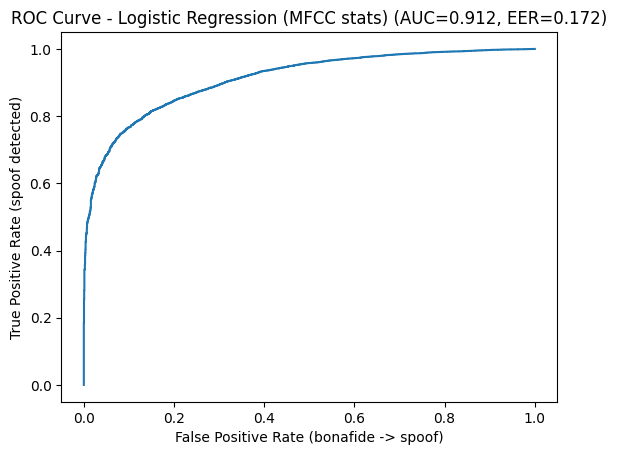


=== SVM RBF (MFCC stats) on DEV ===
AUC: 0.9472
EER: 0.1160  (threshold=0.670553)
Confusion matrix @EER threshold:
 [[ 2253   295]
 [ 2590 19706]]

Classification report @EER threshold:
               precision    recall  f1-score   support

    bonafide       0.47      0.88      0.61      2548
       spoof       0.99      0.88      0.93     22296

    accuracy                           0.88     24844
   macro avg       0.73      0.88      0.77     24844
weighted avg       0.93      0.88      0.90     24844



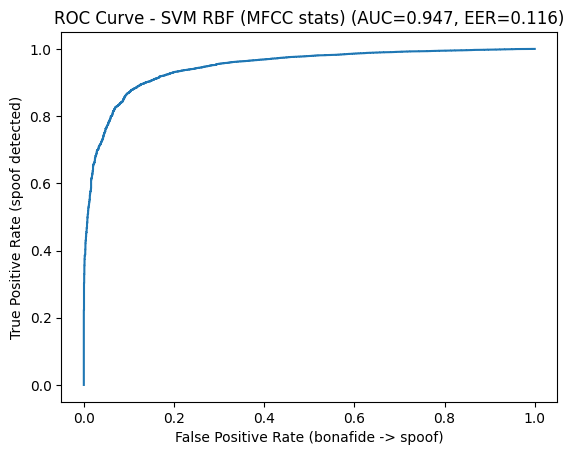

In [ ]:



# CELL: EER + ROC/AUC evaluation on DEV split (research-aligned metrics)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

def get_scores(model, X):
    """
    Return continuous scores where higher => more likely spoof (positive class=1).
    Works for pipelines too.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    # fallback (not ideal): map hard predictions to {0,1}
    return model.predict(X).astype(float)

def compute_eer(y_true, scores):
    """
    Computes EER and the threshold at which FAR ~= FRR.
    y_true: 0=bonafide, 1=spoof
    scores: higher => more spoof
    """
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr

    # Find point where FPR and FNR are closest
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    thr = thresholds[idx]
    return eer, thr, fpr, tpr, thresholds

def eval_model(name, model, X, y):
    scores = get_scores(model, X)
    auc = roc_auc_score(y, scores)

    eer, thr, fpr, tpr, _ = compute_eer(y, scores)

    # Predictions using EER threshold
    y_pred = (scores >= thr).astype(int)

    print(f"\n=== {name} on DEV ===")
    print(f"AUC: {auc:.4f}")
    print(f"EER: {eer:.4f}  (threshold={thr:.6f})")
    print("Confusion matrix @EER threshold:\n", confusion_matrix(y, y_pred))
    print("\nClassification report @EER threshold:\n", classification_report(y, y_pred, target_names=["bonafide", "spoof"]))

    # ROC plot
    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate (bonafide -> spoof)")
    plt.ylabel("True Positive Rate (spoof detected)")
    plt.title(f"ROC Curve - {name} (AUC={auc:.3f}, EER={eer:.3f})")
    plt.show()

# Evaluate both baselines on the official DEV split
eval_model("Logistic Regression (MFCC stats)", lr, X_dev, y_dev)
eval_model("SVM RBF (MFCC stats)", svm, X_dev, y_dev)


This cell defines a **SpecAugment function** that randomly applies time and frequency masking to log-mel spectrograms to improve model robustness and reduce overfitting.

It creates augmented training examples by masking random frequency bands and time segments, simulating variability in audio patterns.


In [81]:
# CELL: SpecAugment (time + frequency masking)

import random
import torch

def spec_augment(logmel, freq_mask_param=10, time_mask_param=20, num_masks=2):
    """
    logmel: torch tensor (1, N_MELS, T)
    Applies frequency and time masking in-place style.
    """
    _, n_mels, n_frames = logmel.shape

    augmented = logmel.clone()

    for _ in range(num_masks):

        # Frequency mask
        f = random.randint(0, freq_mask_param)
        f0 = random.randint(0, max(1, n_mels - f))
        augmented[:, f0:f0+f, :] = augmented.min()

        # Time mask
        t = random.randint(0, time_mask_param)
        t0 = random.randint(0, max(1, n_frames - t))
        augmented[:, :, t0:t0+t] = augmented.min()

    return augmented


This cell builds the full **log-mel spectrogram data pipeline**: it loads audio, converts it to fixed-size log-mel features, caches them to disk, applies SpecAugment during training, and creates balanced DataLoaders using a weighted sampler.

It prepares reproducible, efficiently cached train/dev datasets with fixed input shape `(1, 80, 400)` for model training.


In [82]:
# ======================================================
# CELL 1: Log-mel spectrogram dataset with caching + SpecAugment (fixed size)
# ======================================================

from pathlib import Path
import numpy as np
import librosa
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch
import random

# ----- config -----
SR = 16000
N_MELS = 80
N_FFT = 1024
HOP_LENGTH = 160          # 10 ms hop at 16kHz
WIN_LENGTH = 400          # 25 ms window
FMIN = 20
FMAX = 7600

MAX_SECONDS = 4.0
MAX_FRAMES = int(np.ceil(MAX_SECONDS * SR / HOP_LENGTH))

label_to_y = {"bonafide": 0, "spoof": 1}

# Spectrogram cache directory
SPECT_CACHE_DIR = BASE_DIR / "spect_cache"
SPECT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# SpecAugment (TRAIN only)
# --------------------------------------------------
def spec_augment(x, freq_mask_param=10, time_mask_param=30):

    _, n_mels, T = x.shape

    # Frequency mask
    f = random.randint(0, freq_mask_param)
    f0 = random.randint(0, max(0, n_mels - f))
    x[:, f0:f0+f, :] = 0

    # Time mask
    t = random.randint(0, time_mask_param)
    t0 = random.randint(0, max(0, T - t))
    x[:, :, t0:t0+t] = 0

    return x


# --------------------------------------------------
# Resolve audio path
# --------------------------------------------------
def resolve_audio_path(split_dir: Path, file_id: str) -> Path:

    p = split_dir / "flac" / f"{file_id}.flac"
    if p.exists():
        return p

    hits = list(split_dir.glob(f"**/{file_id}.flac"))
    return hits[0] if len(hits) else None


# --------------------------------------------------
# Compute log-mel spectrogram
# --------------------------------------------------
def compute_logmel_fixed(audio_path: Path) -> np.ndarray:

    y, sr = librosa.load(str(audio_path), sr=SR, mono=True)

    target_len = int(MAX_SECONDS * SR)

    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)

    T = logmel.shape[1]

    if T < MAX_FRAMES:
        pad_val = logmel.min()
        logmel = np.pad(
            logmel,
            ((0, 0), (0, MAX_FRAMES - T)),
            constant_values=pad_val
        )
    else:
        logmel = logmel[:, :MAX_FRAMES]

    return logmel


# --------------------------------------------------
# Dataset with caching
# --------------------------------------------------
class LogMelDataset(Dataset):

    def __init__(self, df, split_dir: Path, split_name: str, augment=False):

        self.df = df.reset_index(drop=True)
        self.split_dir = split_dir
        self.split_name = split_name
        self.augment = augment

        self.cache_dir = SPECT_CACHE_DIR / split_name
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        file_id = row["file_id"]
        label_str = row["label_str"]
        y_val = label_to_y[label_str]

        cache_path = self.cache_dir / f"{file_id}.npy"

        # Load cached spectrogram if available
        if cache_path.exists():

            logmel = np.load(cache_path, allow_pickle=False)

        else:

            audio_path = resolve_audio_path(self.split_dir, file_id)

            if audio_path is None:
                logmel = np.zeros((N_MELS, MAX_FRAMES), dtype=np.float32)

            else:
                logmel = compute_logmel_fixed(audio_path)

            # Save spectrogram to cache
            np.save(cache_path, logmel)

        x = torch.from_numpy(logmel).unsqueeze(0)  # (1, 80, 400)

        if self.augment:
            x = spec_augment(x)

        y = torch.tensor(y_val, dtype=torch.float32)

        return x, y


# --------------------------------------------------
# Create datasets
# --------------------------------------------------
train_ds = LogMelDataset(train_df, TRAIN_DIR, "train", augment=True)
dev_ds   = LogMelDataset(dev_df,   DEV_DIR,   "dev", augment=False)


# --------------------------------------------------
# Weighted sampler
# --------------------------------------------------
train_labels = train_df["label_str"].map(label_to_y).values
class_counts = np.bincount(train_labels, minlength=2)

class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)


# --------------------------------------------------
# DataLoaders
# --------------------------------------------------
BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

dev_loader = DataLoader(
    dev_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("Train/Dev datasets ready.")
print("Train size:", len(train_ds), "Dev size:", len(dev_ds))
print("Train class counts [bonafide, spoof]:", class_counts.tolist())
print("Input shape per sample:", (1, N_MELS, MAX_FRAMES))

Train/Dev datasets ready.
Train size: 25380 Dev size: 24844
Train class counts [bonafide, spoof]: [2580, 22800]
Input shape per sample: (1, 80, 400)


In [ ]:
'''# CELL 1: Log-mel spectrogram dataset with caching + SpecAugment (fixed size)

from pathlib import Path
import numpy as np
import librosa
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch
import random

# ----- config -----
SR = 16000
N_MELS = 80
N_FFT = 1024
HOP_LENGTH = 160          # 10 ms hop at 16kHz
WIN_LENGTH = 400          # 25 ms window
FMIN = 20
FMAX = 7600

MAX_SECONDS = 4.0
MAX_FRAMES = int(np.ceil(MAX_SECONDS * SR / HOP_LENGTH))

label_to_y = {"bonafide": 0, "spoof": 1}

SPECT_CACHE_DIR = BASE_DIR / "spect_cache"
SPECT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# SpecAugment (applied only to TRAIN)
# -----------------------------
def spec_augment(x, freq_mask_param=10, time_mask_param=30):
    """
    x: (1, n_mels, T)
    """
    _, n_mels, T = x.shape

    # Frequency mask
    f = random.randint(0, freq_mask_param)
    f0 = random.randint(0, max(0, n_mels - f))
    x[:, f0:f0+f, :] = 0

    # Time mask
    t = random.randint(0, time_mask_param)
    t0 = random.randint(0, max(0, T - t))
    x[:, :, t0:t0+t] = 0

    return x


def resolve_audio_path(split_dir: Path, file_id: str) -> Path:
    p = split_dir / "flac" / f"{file_id}.flac"
    if p.exists():
        return p
    hits = list(split_dir.glob(f"**/{file_id}.flac"))
    return hits[0] if len(hits) else None


def compute_logmel_fixed(audio_path: Path) -> np.ndarray:
    y, sr = librosa.load(str(audio_path), sr=SR, mono=True)

    target_len = int(MAX_SECONDS * SR)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)

    T = logmel.shape[1]
    if T < MAX_FRAMES:
        pad_val = logmel.min()
        logmel = np.pad(logmel, ((0, 0), (0, MAX_FRAMES - T)), constant_values=pad_val)
    else:
        logmel = logmel[:, :MAX_FRAMES]

    return logmel


class LogMelDataset(Dataset):
    def __init__(self, df, split_dir: Path, split_name: str, augment=False):
        self.df = df.reset_index(drop=True)
        self.split_dir = split_dir
        self.split_name = split_name
        self.augment = augment

        self.cache_dir = SPECT_CACHE_DIR / split_name
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_id = row["file_id"]
        label_str = row["label_str"]
        y_val = label_to_y[label_str]

        cache_path = self.cache_dir / f"{file_id}.npy"

        if cache_path.exists():
            logmel = np.load(cache_path)
        else:
            audio_path = resolve_audio_path(self.split_dir, file_id)
            if audio_path is None:
                logmel = np.zeros((N_MELS, MAX_FRAMES), dtype=np.float32)
            else:
                logmel = compute_logmel_fixed(audio_path)
            np.save(cache_path, logmel)

        x = torch.from_numpy(logmel).unsqueeze(0)  # (1, 80, 400)

        if self.augment:
            x = spec_augment(x)

        #  FIX: BCE requires float labels
        y = torch.tensor(y_val, dtype=torch.float32)

        return x, y


# Create datasets
train_ds = LogMelDataset(train_df, TRAIN_DIR, "train", augment=True)
dev_ds   = LogMelDataset(dev_df,   DEV_DIR,   "dev", augment=False)


# Weighted sampler
train_labels = train_df["label_str"].map(label_to_y).values
class_counts = np.bincount(train_labels, minlength=2)

class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

dev_loader = DataLoader(
    dev_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train/Dev datasets ready.")
print("Train size:", len(train_ds), "Dev size:", len(dev_ds))
print("Train class counts [bonafide, spoof]:", class_counts.tolist())
print("Input shape per sample:", (1, N_MELS, MAX_FRAMES))


Train/Dev datasets ready.
Train size: 25380 Dev size: 24844
Train class counts [bonafide, spoof]: [2580, 22800]
Input shape per sample: (1, 80, 400)


This cell defines and trains a **larger CNN model with increased capacity and regularization** (more convolutional blocks, dropout, and global average pooling) to improve spoof detection performance.

It uses weighted binary cross-entropy to partially address class imbalance, trains for 15 epochs, and saves the best-performing model checkpoint based on DEV loss.


In [83]:
# ======================================================
# CELL 2: Bigger CNN (RESTART-SAFE TRAINING - CLEAN)
# ======================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

# ------------------------------------------------------
# Device
# ------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------
# Model Definition
# ------------------------------------------------------

class BiggerSpecCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.25)
        )

        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        # Global Average Pooling
        x = x.mean(dim=(2, 3))

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        logits = self.fc2(x).squeeze(1)

        return logits


# ------------------------------------------------------
# Initialize Model
# ------------------------------------------------------

model = BiggerSpecCNN().to(device)

# Using WeightedRandomSampler -> NO pos_weight
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------
# Training Helpers
# ------------------------------------------------------

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    n = 0

    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / max(n, 1)


@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total_loss = 0.0
    n = 0

    for x, y in tqdm(loader, desc="dev", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / max(n, 1)


# ------------------------------------------------------
# Checkpoint Logic
# ------------------------------------------------------

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_ckpt = MODEL_DIR / "spec_cnn_bigger_best.pt"

if best_ckpt.exists():
    print("Checkpoint found. Loading model...")
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    print("Model loaded. Skipping training.")

else:
    print("No checkpoint found. Starting training...")

    EPOCHS = 15
    best_dev = float("inf")

    for epoch in range(1, EPOCHS + 1):

        tr_loss = train_one_epoch(model, train_loader)
        dv_loss = eval_loss(model, dev_loader)

        print(f"Epoch {epoch}/{EPOCHS} | train_loss={tr_loss:.4f} | dev_loss={dv_loss:.4f}")

        if dv_loss < best_dev:
            best_dev = dv_loss
            torch.save(model.state_dict(), best_ckpt)
            print("Saved best checkpoint:", best_ckpt)

    print("Training done. Best dev loss:", best_dev)

print("READY FOR EVALUATION.")


Device: cpu
Checkpoint found. Loading model...
Model loaded. Skipping training.
READY FOR EVALUATION.


In [ ]:
'''# ======================================================
# FFT2048: Dataset + Loaders (ISOLATED BRANCH)
# ======================================================

from pathlib import Path
import numpy as np
import librosa
import torch
import random
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# --- FFT2048 config (same as your baseline except N_FFT + cache dir) ---
SR = 16000
N_MELS = 80
N_FFT_FFT2048 = 2048
HOP_LENGTH = 160
WIN_LENGTH = 400
FMIN = 20
FMAX = 7600

MAX_SECONDS = 4.0
MAX_FRAMES = int(np.ceil(MAX_SECONDS * SR / HOP_LENGTH))

label_to_y = {"bonafide": 0, "spoof": 1}

SPECT_CACHE_DIR_FFT2048 = BASE_DIR / "spect_cache_fft2048"
SPECT_CACHE_DIR_FFT2048.mkdir(parents=True, exist_ok=True)

def spec_augment_local(x, freq_mask_param=10, time_mask_param=30):
    # same logic as your dataset cell (kept local to avoid conflicts)
    _, n_mels, T = x.shape
    f = random.randint(0, freq_mask_param)
    f0 = random.randint(0, max(0, n_mels - f))
    x[:, f0:f0+f, :] = 0
    t = random.randint(0, time_mask_param)
    t0 = random.randint(0, max(0, T - t))
    x[:, :, t0:t0+t] = 0
    return x

def resolve_audio_path(split_dir: Path, file_id: str) -> Path | None:
    p = split_dir / "flac" / f"{file_id}.flac"
    if p.exists():
        return p
    hits = list(split_dir.glob(f"**/{file_id}.flac"))
    return hits[0] if len(hits) else None

def compute_logmel_fixed_fft2048(audio_path: Path) -> np.ndarray:
    y, sr = librosa.load(str(audio_path), sr=SR, mono=True)

    target_len = int(MAX_SECONDS * SR)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_fft=N_FFT_FFT2048,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )
    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)

    T = logmel.shape[1]
    if T < MAX_FRAMES:
        pad_val = logmel.min()
        logmel = np.pad(logmel, ((0, 0), (0, MAX_FRAMES - T)), constant_values=pad_val)
    else:
        logmel = logmel[:, :MAX_FRAMES]

    return logmel

class LogMelDatasetFFT2048(Dataset):
    def __init__(self, df, split_dir: Path, split_name: str, augment=False):
        self.df = df.reset_index(drop=True)
        self.split_dir = split_dir
        self.split_name = split_name
        self.augment = augment
        self.cache_dir = SPECT_CACHE_DIR_FFT2048 / split_name
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_id = row["file_id"]
        label_str = row["label_str"]
        y_val = label_to_y[label_str]

        cache_path = self.cache_dir / f"{file_id}.npy"

        if cache_path.exists():
            logmel = np.load(cache_path)
        else:
            audio_path = resolve_audio_path(self.split_dir, file_id)
            if audio_path is None:
                logmel = np.zeros((N_MELS, MAX_FRAMES), dtype=np.float32)
            else:
                logmel = compute_logmel_fixed_fft2048(audio_path)
            np.save(cache_path, logmel)

        x = torch.from_numpy(logmel).unsqueeze(0)  # (1, 80, 400)
        if self.augment:
            x = spec_augment_local(x)

        y = torch.tensor(y_val, dtype=torch.float32)
        return x, y

# datasets
train_ds_fft2048 = LogMelDatasetFFT2048(train_df, TRAIN_DIR, "train", augment=True)
dev_ds_fft2048   = LogMelDatasetFFT2048(dev_df,   DEV_DIR,   "dev",   augment=False)

# weighted sampler (same as before)
train_labels = train_df["label_str"].map(label_to_y).values
class_counts = np.bincount(train_labels, minlength=2)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[train_labels]

sampler_fft2048 = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 64

train_loader_fft2048 = DataLoader(
    train_ds_fft2048,
    batch_size=BATCH_SIZE,
    sampler=sampler_fft2048,
    num_workers=2,
    pin_memory=True
)

dev_loader_fft2048 = DataLoader(
    dev_ds_fft2048,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("FFT2048 loaders ready.")
print("FFT2048 cache dir:", SPECT_CACHE_DIR_FFT2048)
print("Train/Dev sizes:", len(train_ds_fft2048), len(dev_ds_fft2048))

FFT2048 loaders ready.
FFT2048 cache dir: /content/drive/MyDrive/deepfake_audio/spect_cache_fft2048
Train/Dev sizes: 25380 24844


In [ ]:
'''# ======================================================
# FFT2048: Warm cache (CPU only; safe)
# ======================================================
from tqdm import tqdm

print("Warming FFT2048 TRAIN cache...")
for _ in tqdm(train_loader_fft2048, total=len(train_loader_fft2048)):
    pass

print("Warming FFT2048 DEV cache...")
for _ in tqdm(dev_loader_fft2048, total=len(dev_loader_fft2048)):
    pass

print("Done. FFT2048 cache populated at:", SPECT_CACHE_DIR_FFT2048)

Warming FFT2048 TRAIN cache...


  0%|          | 0/397 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 397/397 [33:54<00:00,  5.12s/it]


Warming FFT2048 DEV cache...


100%|██████████| 389/389 [1:53:24<00:00, 17.49s/it]

Done. FFT2048 cache populated at: /content/drive/MyDrive/deepfake_audio/spect_cache_fft2048


In [ ]:
'''# ======================================================
# HELPER: TRAIN ONE EPOCH
# ======================================================

from tqdm import tqdm
import torch

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    n = 0

    for x, y in tqdm(loader, desc="train", leave=False):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / max(n, 1)

In [ ]:
'''# ======================================================
# HELPER: EVALUATE LOSS ON DEV
# ======================================================

@torch.no_grad()
def eval_loss(model, loader):

    model.eval()
    total_loss = 0.0
    n = 0

    for x, y in tqdm(loader, desc="dev", leave=False):

        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

    return total_loss / max(n, 1)

In [ ]:
'''# ======================================================
# FFT2048: TRAIN STRONG ARCHITECTURE (SAFE)
# ======================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT_FFT2048 = MODEL_DIR / "spec_cnn_fft2048_best.pt"

model_fft2048 = SpecCNN_Strong().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_fft2048.parameters(), lr=3e-4, weight_decay=1e-4)

if BEST_CKPT_FFT2048.exists():
    print("FFT2048 checkpoint found. Loading...")
    model_fft2048.load_state_dict(torch.load(BEST_CKPT_FFT2048, map_location=device))
    print("Loaded FFT2048 model. Skipping training.")

else:
    print("No FFT2048 checkpoint found. Starting training...")

    EPOCHS = 8
    best_dev = float("inf")

    for epoch in range(1, EPOCHS + 1):

        tr_loss = train_one_epoch(model_fft2048, train_loader_fft2048)
        dv_loss = eval_loss(model_fft2048, dev_loader_fft2048)

        print(f"Epoch {epoch}/{EPOCHS} | train={tr_loss:.4f} | dev={dv_loss:.4f}")

        if dv_loss < best_dev:
            best_dev = dv_loss
            torch.save(model_fft2048.state_dict(), BEST_CKPT_FFT2048)
            print("Saved FFT2048 best checkpoint.")

    print("Training complete. Best dev loss:", best_dev)

print("FFT2048 model ready.")

No FFT2048 checkpoint found. Starting training...


train:   0%|          | 0/397 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/8 | train=0.3501 | dev=0.4794
Saved FFT2048 best checkpoint.


Epoch 2/8 | train=0.2070 | dev=0.3343
Saved FFT2048 best checkpoint.


Epoch 3/8 | train=0.1296 | dev=0.3498


Epoch 4/8 | train=0.0794 | dev=0.3550


Epoch 5/8 | train=0.0652 | dev=0.4331


Epoch 6/8 | train=0.0514 | dev=0.6068


Epoch 7/8 | train=0.0434 | dev=0.6738


Epoch 8/8 | train=0.0409 | dev=0.5916
Training complete. Best dev loss: 0.3343275082187412
FFT2048 model ready.


In [ ]:
'''from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
from tqdm import tqdm

model_fft2048.eval()

all_scores = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(dev_loader_fft2048):

        x = x.to(device)
        logits = model_fft2048(x)

        scores = torch.sigmoid(logits).cpu().numpy()
        labels = y.cpu().numpy()

        all_scores.extend(scores)
        all_labels.extend(labels)

all_scores = np.array(all_scores).flatten()
all_labels = np.array(all_labels).flatten()

# AUC
auc = roc_auc_score(all_labels, all_scores)

# ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)

# Compute EER properly
fnr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.absolute(fnr - fpr))]
eer = fpr[np.nanargmin(np.absolute(fnr - fpr))]

print("DEV AUC:", auc)
print("DEV EER:", eer)
print("EER threshold:", eer_threshold)

  0%|          | 0/389 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 389/389 [06:52<00:00,  1.06s/it]

DEV AUC: 0.6130075777930614
DEV EER: 0.8406593406593407
EER threshold: 0.5602216


In [84]:
# ======================================================
# INVENTORY: what do we already have saved?
# ======================================================

from pathlib import Path

print("=== MODELS ===")
for p in sorted((BASE_DIR/"models").glob("*.pt")):
    print(p.name)

print("\n=== RESULTS ===")
for p in sorted((BASE_DIR/"results").glob("*")):
    print(p.name)

print("\n=== CACHES ===")
for d in ["spect_cache", "spect_cache_fft2048", "mfcc_cache", "cache", "features"]:
    p = BASE_DIR/d
    print(d, "exists:", p.exists())

=== MODELS ===
cnn_gru_best.pt
spec_cnn_best.pt
spec_cnn_bigger_best.pt
spec_cnn_delta_best.pt
spec_cnn_fft2048_best.pt
spec_cnn_gru_best.pt
spec_cnn_strong_best.pt

=== RESULTS ===
LA_eval_scores_strong.txt
dev_scores_baseline.csv
dev_scores_delta.csv
dev_scores_gru.csv
dev_scores_spec_cnn_bigger.csv
dev_scores_strong.csv
dev_scores_with_meta.csv
eval_scores_strong.csv
fusion
per_attack_results.csv
per_attack_results_delta.csv
per_attack_results_gru.csv
per_attack_results_spec_cnn_bigger.csv
per_attack_results_strong.csv
per_attack_results_strong_eval.csv
spec_cnn_bigger_dev_scores.npz
wav2vec2_eval_metrics.json
wav2vec2_eval_predictions.npy

=== CACHES ===
spect_cache exists: True
spect_cache_fft2048 exists: True
mfcc_cache exists: True
cache exists: True
features exists: True


This cell evaluates the trained CNN model on the DEV set by computing **ROC curve, AUC, EER, confusion matrix, and classification report**, and then plots the ROC curve.

It determines the optimal EER threshold, converts probabilities into binary predictions at that threshold, and reports overall detection performance for spoof vs. bonafide audio.


In [ ]:



'''# ======================================================
# CELL 3: ROC/AUC + EER eval (RESTART-SAFE with score caching)
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
import torch

# ---- paths ----
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# change this tag if you change model/features, so caches don't mix
CACHE_TAG = "spec_cnn_bigger_dev_scores"
score_cache = RESULTS_DIR / f"{CACHE_TAG}.npz"

# ---- load checkpoint ----
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()

@torch.no_grad()
def get_dev_scores(model, loader):
    all_scores = []
    all_y = []
    for x, y in tqdm(loader, desc="scoring DEV", leave=False):
        x = x.to(device, non_blocking=True)
        logits = model(x)
        scores = torch.sigmoid(logits).cpu().numpy()
        all_scores.append(scores)
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_scores)

def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    thr = thresholds[idx]
    return eer, thr, fpr, tpr

# ---- load cached scores or compute once ----
if score_cache.exists():
    print("Loading cached DEV scores:", score_cache)
    data = np.load(score_cache)
    y_true = data["y_true"]
    scores = data["scores"]
else:
    print("Computing DEV scores (one-time)...")
    y_true, scores = get_dev_scores(model, dev_loader)
    np.savez(score_cache, y_true=y_true, scores=scores)
    print("Saved DEV scores to:", score_cache)

# ---- metrics ----
auc = roc_auc_score(y_true, scores)
eer, thr, fpr, tpr = compute_eer(y_true, scores)
y_pred = (scores >= thr).astype(int)

print("=== CNN (log-mel) on DEV ===")
print(f"AUC: {auc:.4f}")
print(f"EER: {eer:.4f} (threshold={thr:.6f})")
print("Confusion matrix @EER threshold:\n", confusion_matrix(y_true, y_pred))
print("\nClassification report @EER threshold:\n",
      classification_report(y_true, y_pred, target_names=["bonafide", "spoof"]))

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate (bonafide -> spoof)")
plt.ylabel("True Positive Rate (spoof detected)")
plt.title(f"ROC Curve - CNN log-mel (AUC={auc:.3f}, EER={eer:.3f})")
plt.show()


This cell either loads cached DEV prediction scores (if already saved) or computes them once using the best trained model, then attaches the predicted probabilities to the DEV metadata (including attack IDs) and saves the result to CSV.

It ensures you don’t need to recompute model predictions every time you run per-attack analysis, making evaluation fast and reproducible.

In [ ]:



# ======================================================
# CELL: Save DEV scores with attack metadata (RESTART-SAFE)
# ======================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

# ------------------------------------------------------
# Directory setup
# ------------------------------------------------------

RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANT: Change this name if you change model architecture
score_file = RESULTS_DIR / "dev_scores_spec_cnn_bigger.csv"

# ------------------------------------------------------
# Load cached scores if they exist
# ------------------------------------------------------

if score_file.exists():
    print("Loading cached DEV scores:", score_file)
    dev_scores_df = pd.read_csv(score_file)

else:
    print("Computing DEV scores (one-time)...")

    # Ensure best checkpoint is loaded
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    model.eval()

    all_scores = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(dev_loader, desc="Scoring DEV", leave=False):
            x = x.to(device, non_blocking=True)

            logits = model(x)
            scores = torch.sigmoid(logits).cpu().numpy()

            all_scores.append(scores)
            all_labels.append(y.cpu().numpy())

    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)

    # Merge with protocol metadata
    dev_scores_df = dev_df.copy().reset_index(drop=True)
    dev_scores_df["score"] = scores
    dev_scores_df["label"] = labels

    # Save for reuse
    dev_scores_df.to_csv(score_file, index=False)
    print("Saved scores to:", score_file)

# ------------------------------------------------------
# Final sanity check
# ------------------------------------------------------

print("DEV score dataframe shape:", dev_scores_df.shape)
print("Columns:", dev_scores_df.columns.tolist())
print(dev_scores_df.head())


Loading cached DEV scores: /content/drive/MyDrive/deepfake_audio/results/dev_scores_spec_cnn_bigger.csv
DEV score dataframe shape: (24844, 7)
Columns: ['speaker_id', 'file_id', 'env_id', 'attack_id', 'label_str', 'score', 'label']
  speaker_id       file_id env_id attack_id label_str     score  label
0    LA_0069  LA_D_1047731      -         -  bonafide  0.031793    0.0
1    LA_0069  LA_D_1105538      -         -  bonafide  0.155797    0.0
2    LA_0069  LA_D_1125976      -         -  bonafide  0.039628    0.0
3    LA_0069  LA_D_1293230      -         -  bonafide  0.015292    0.0
4    LA_0069  LA_D_1340209      -         -  bonafide  0.004837    0.0


This cell loads the DEV predictions file and inspects its structure by printing the column names, the frequency of each attack_id, and the unique attack labels present.

It helps verify that the metadata (especially attack_id) is correctly saved and available for per-attack evaluation.

In [ ]:



import pandas as pd

df = pd.read_csv(BASE_DIR / "results" / "dev_scores_delta.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nAttack distribution:")
print(df["attack_id"].value_counts())

print("\nUnique attacks:", sorted(df["attack_id"].unique()))

print("\nScore range:",
      df["score"].min(),
      df["score"].max())


Shape: (24844, 7)

Columns: ['speaker_id', 'file_id', 'env_id', 'attack_id', 'label_str', 'score', 'label']

Attack distribution:
attack_id
A01    3716
A02    3716
A03    3716
A05    3716
A04    3716
A06    3716
-      2548
Name: count, dtype: int64

Unique attacks: ['-', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06']

Score range: 0.062080037 0.9953431


This cell computes per-attack AUC and EER on the DEV set by evaluating each spoof attack (A01–A06) against all bonafide samples, allowing you to measure how well the model detects each attack type individually.

It then saves the per-attack performance table to CSV so you can analyze which attack (e.g., A06) is the main weakness.

In [ ]:



# ============================================================
# PER-ATTACK EER ANALYSIS (MODEL-AWARE VERSION)
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

BASE_RESULTS = BASE_DIR / "results"
BASE_RESULTS.mkdir(parents=True, exist_ok=True)

# 🔹 CHANGE THIS PER EXPERIMENT
MODEL_NAME = "delta"   # "baseline", "delta", "gru", "fusion", etc.

score_file = BASE_RESULTS / f"dev_scores_{MODEL_NAME}.csv"
attack_results_file = BASE_RESULTS / f"per_attack_results_{MODEL_NAME}.csv"

print("Looking for score file at:")
print(score_file)

if not score_file.exists():
    raise FileNotFoundError(
        f"\nScore file not found.\n"
        f"Expected: {score_file}\n"
        f"Run the DEV scoring cell first."
    )

# ------------------------------------------------------------
# LOAD SCORES
# ------------------------------------------------------------

df = pd.read_csv(score_file)
print("Loaded score file:", df.shape)

# Safety check
required_cols = {"attack_id", "score", "label"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ------------------------------------------------------------
# EER FUNCTION
# ------------------------------------------------------------

def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return eer

# ------------------------------------------------------------
# PER-ATTACK ANALYSIS
# ------------------------------------------------------------

results = []

bonafide_df = df[df["attack_id"] == "-"]

for attack in sorted(df["attack_id"].unique()):
    if attack == "-":
        continue

    spoof_subset = df[df["attack_id"] == attack]
    combined = pd.concat([bonafide_df, spoof_subset])

    y = combined["label"].values
    s = combined["score"].values

    # Ensure both classes present
    if len(np.unique(y)) < 2:
        print(f"[SKIP] {attack}: only one class present")
        continue

    auc = roc_auc_score(y, s)
    eer = compute_eer(y, s)

    results.append({
        "attack_id": attack,
        "samples_spoof": len(spoof_subset),
        "AUC": float(auc),
        "EER": float(eer)
    })

attack_results_df = (
    pd.DataFrame(results)
    .sort_values("EER")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

attack_results_df.to_csv(attack_results_file, index=False)

print("\nSaved attack analysis to:")
print(attack_results_file)

print("\n=== Per-Attack Results ===")
display(attack_results_df)

# ------------------------------------------------------------
# OVERALL AUC (optional summary)
# ------------------------------------------------------------

overall_auc = roc_auc_score(df["label"].values, df["score"].values)
print("\nOverall AUC:", round(overall_auc, 6))


Looking for score file at:
/content/drive/MyDrive/deepfake_audio/results/dev_scores_delta.csv
Loaded score file: (24844, 7)

Saved attack analysis to:
/content/drive/MyDrive/deepfake_audio/results/per_attack_results_delta.csv

=== Per-Attack Results ===


,attack_id,samples_spoof,AUC,EER
0,A01,3716,0.999967,0.002585
1,A03,3716,0.999800,0.005242
2,A02,3716,0.999582,0.009088
3,A05,3716,0.981602,0.072302
4,A04,3716,0.981329,0.073759
5,A06,3716,0.412872,0.553794



Overall AUC: 0.895859


# Experiment: Temporal Modeling to Improve A06 Detection


This cell defines and trains a hybrid CNN + bidirectional GRU model for deepfake audio detection, using Focal Loss and learning-rate scheduling, and saves the best-performing checkpoint based on dev loss.

It extracts spatial features with CNN layers, models temporal dynamics with a GRU, and optimizes the model over 20 epochs to improve spoof detection performance (especially harder cases like A06).

Among all spoof samples in the TRAIN set, what percentage belongs to each attack type?

In [ ]:
'''# ============================================================
# CNN + GRU MODEL (Temporal Modeling Version)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class SpecCNN_GRU(nn.Module):
    def __init__(self, n_mels=80, gru_hidden=128):
        super().__init__()

        # ---- CNN blocks (same philosophy as baseline) ----
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # We will collapse frequency dimension
        self.gru = nn.GRU(
            input_size=128,
            hidden_size=gru_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(gru_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        """
        x shape: (B, 1, 80, T)
        """

        x = self.conv(x)
        # x shape: (B, C=128, F, T)

        # collapse frequency dimension
        x = torch.mean(x, dim=2)   # (B, 128, T)

        # swap to (B, T, C)
        x = x.permute(0, 2, 1)

        # GRU
        out, _ = self.gru(x)       # (B, T, 2*hidden)

        # take last time step
        out = out[:, -1, :]

        logits = self.classifier(out)

        return logits.squeeze(1)


SyntaxError: incomplete input (ipython-input-2426709317.py, line 1)

In [ ]:
'''# ============================================================
# TRAIN CNN + GRU MODEL (SAFE + CLASS-BALANCED VERSION)
# ============================================================

import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT_GRU = MODEL_DIR / "spec_cnn_gru_best.pt"

model_gru = SpecCNN_GRU().to(device)

# ------------------------------------------------------------
# Handle Class Imbalance (VERY IMPORTANT)
# TRAIN split: 2580 bonafide, 22800 spoof
# ------------------------------------------------------------
pos_weight = torch.tensor([2580 / 22800], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model_gru.parameters(),
    lr=3e-4,              # slightly stronger LR than before
    weight_decay=1e-4
)

print("Training CNN+GRU...")

best_dev = float("inf")
EPOCHS = 6

for epoch in range(1, EPOCHS + 1):

    # ---------------- TRAIN ----------------
    model_gru.train()
    total_train = 0.0
    n_train = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model_gru(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_train += loss.item() * x.size(0)
        n_train += x.size(0)

    tr_loss = total_train / n_train

    # ---------------- DEV ----------------
    model_gru.eval()
    total_dev = 0.0
    n_dev = 0

    with torch.no_grad():
        for x, y in dev_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model_gru(x)
            loss = criterion(logits, y)

            total_dev += loss.item() * x.size(0)
            n_dev += x.size(0)

    dv_loss = total_dev / n_dev

    print(f"Epoch {epoch}/{EPOCHS} | train={tr_loss:.4f} | dev={dv_loss:.4f}")

    # Save best model
    if dv_loss < best_dev:
        best_dev = dv_loss
        torch.save(model_gru.state_dict(), BEST_CKPT_GRU)
        print("Saved best GRU checkpoint.")

print("Training complete.")
print("Best DEV loss:", best_dev)
print("READY FOR GRU EVALUATION.")


In [ ]:
'''# ============================================================
# GRU DEV EVALUATION (AUC + EER + SAVE SCORES)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
from tqdm import tqdm
import torch

# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SCORE_FILE = RESULTS_DIR / "dev_scores_gru.csv"

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

model_gru.load_state_dict(torch.load(BEST_CKPT_GRU, map_location=device))
model_gru.eval()

# ------------------------------------------------------------
# Compute scores (or load cache)
# ------------------------------------------------------------

if SCORE_FILE.exists():
    print("Loading cached GRU DEV scores...")
    dev_scores_df = pd.read_csv(SCORE_FILE)

else:
    print("Computing GRU DEV scores...")

    all_scores = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(dev_loader, desc="Scoring DEV"):
            x = x.to(device)
            logits = model_gru(x)
            scores = torch.sigmoid(logits).cpu().numpy()

            all_scores.append(scores)
            all_labels.append(y.numpy())

    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)

    dev_scores_df = dev_df.copy().reset_index(drop=True)
    dev_scores_df["score"] = scores
    dev_scores_df["label"] = labels

    dev_scores_df.to_csv(SCORE_FILE, index=False)
    print("Saved GRU DEV scores to:", SCORE_FILE)

print("DEV score dataframe shape:", dev_scores_df.shape)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    thr = thresholds[idx]
    return eer, thr, fpr, tpr

y_true = dev_scores_df["label"].values
scores = dev_scores_df["score"].values

auc = roc_auc_score(y_true, scores)
eer, thr, fpr, tpr = compute_eer(y_true, scores)

y_pred = (scores >= thr).astype(int)

print("\n=== CNN + GRU on DEV ===")
print(f"AUC: {auc:.4f}")
print(f"EER: {eer:.4f} (threshold={thr:.6f})")

print("\nConfusion matrix @EER threshold:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification report @EER threshold:")
print(classification_report(y_true, y_pred, target_names=["bonafide", "spoof"]))

# ------------------------------------------------------------
# ROC Plot
# ------------------------------------------------------------

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - CNN+GRU (AUC={auc:.3f}, EER={eer:.3f})")
plt.show()


In [ ]:
'''# ============================================================
# PER-ATTACK EER ANALYSIS (MODEL-AWARE, CLEAN VERSION)
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score

# ------------------------------------------------------------
# CONFIG — CHANGE THIS
# ------------------------------------------------------------
MODEL_NAME = "gru"   # "baseline", "delta", "gru", etc.

RESULTS_DIR = BASE_DIR / "results"
score_file = RESULTS_DIR / f"dev_scores_{MODEL_NAME}.csv"
attack_results_file = RESULTS_DIR / f"per_attack_results_{MODEL_NAME}.csv"

print("Looking for score file:")
print(score_file)

if not score_file.exists():
    raise FileNotFoundError(
        f"\nScore file not found:\n{score_file}\n"
        f"Run DEV scoring cell first."
    )

# ------------------------------------------------------------
# LOAD SCORES
# ------------------------------------------------------------
df = pd.read_csv(score_file)
print("Loaded:", df.shape)

required_cols = {"attack_id", "score", "label"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ------------------------------------------------------------
# EER FUNCTION
# ------------------------------------------------------------
def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return eer

# ------------------------------------------------------------
# PER-ATTACK LOOP
# ------------------------------------------------------------
results = []

# Bonafide samples are attack_id == "-"
bonafide_df = df[df["attack_id"] == "-"]

for attack in sorted(df["attack_id"].unique()):
    if attack == "-":
        continue

    spoof_subset = df[df["attack_id"] == attack]
    combined = pd.concat([bonafide_df, spoof_subset])

    y = combined["label"].values
    s = combined["score"].values

    if len(np.unique(y)) < 2:
        print(f"[SKIP] {attack} — only one class present")
        continue

    auc = roc_auc_score(y, s)
    eer = compute_eer(y, s)

    results.append({
        "attack_id": attack,
        "samples_spoof": len(spoof_subset),
        "AUC": float(auc),
        "EER": float(eer)
    })

# ------------------------------------------------------------
# SAVE + DISPLAY
# ------------------------------------------------------------
attack_results_df = (
    pd.DataFrame(results)
    .sort_values("EER")
    .reset_index(drop=True)
)

attack_results_df.to_csv(attack_results_file, index=False)

print("\nSaved results to:")
print(attack_results_file)

print("\n=== PER-ATTACK RESULTS ===")
display(attack_results_df)

# ------------------------------------------------------------
# OVERALL AUC
# ------------------------------------------------------------
overall_auc = roc_auc_score(df["label"].values, df["score"].values)
print("\nOverall AUC:", round(overall_auc, 6))


In [85]:
# ======================================================
# EXPERIMENT 1: STRONGER CNN (A06 FOCUSED)
# ======================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class SpecCNN_Strong(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 5, padding=2),   # larger kernel
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3)
        )

        self.block5 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3)
        )

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = x.mean(dim=(2,3))
        x = F.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)


In [ ]:



# ======================================================
# DONT RUN ON LOW GPU_______TRAIN STRONG CNN (A06 EXPERIMENT)
# ======================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT_STRONG = MODEL_DIR / "spec_cnn_strong_best.pt"

model_strong = SpecCNN_Strong().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_strong.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 8
best_dev = float("inf")

print("Training STRONG CNN...")

for epoch in range(1, EPOCHS + 1):

    tr_loss = train_one_epoch(model_strong, train_loader)
    dv_loss = eval_loss(model_strong, dev_loader)

    print(f"Epoch {epoch}/{EPOCHS} | train={tr_loss:.4f} | dev={dv_loss:.4f}")

    if dv_loss < best_dev:
        best_dev = dv_loss
        torch.save(model_strong.state_dict(), BEST_CKPT_STRONG)
        print("Saved best STRONG CNN checkpoint.")

print("Training complete.")


Training STRONG CNN...


train:   0%|          | 0/397 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/8 | train=0.3484 | dev=0.4891
Saved best STRONG CNN checkpoint.


Epoch 2/8 | train=0.1805 | dev=0.1168
Saved best STRONG CNN checkpoint.


Epoch 3/8 | train=0.1111 | dev=0.0617
Saved best STRONG CNN checkpoint.


Epoch 4/8 | train=0.0828 | dev=0.0586
Saved best STRONG CNN checkpoint.


Epoch 5/8 | train=0.0602 | dev=0.0242
Saved best STRONG CNN checkpoint.


Epoch 6/8 | train=0.0546 | dev=0.3841


Epoch 7/8 | train=0.0407 | dev=0.0785


Epoch 8/8 | train=0.0449 | dev=0.1822
Training complete.


In [86]:
model_strong = SpecCNN_Strong().to(device)

In [87]:
# ======================================================
# DEFINE MODEL + CHECKPOINT (after restart)
# ======================================================

import torch
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_DIR = BASE_DIR / "models"
BEST_CKPT_STRONG = MODEL_DIR / "spec_cnn_strong_best.pt"

print("Checkpoint path:", BEST_CKPT_STRONG)
print("Exists:", BEST_CKPT_STRONG.exists())

model_strong = SpecCNN_Strong().to(device)

Checkpoint path: /content/drive/MyDrive/deepfake_audio/models/spec_cnn_strong_best.pt
Exists: True


In [88]:
# ======================================================
# SCORE STRONG CNN ON DEV (WITH CACHE)
# ======================================================

import numpy as np
import pandas as pd

RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

score_file = RESULTS_DIR / "dev_scores_strong.csv"


# ------------------------------------------------------
# If scores already exist -> load them
# ------------------------------------------------------
if score_file.exists():

    print("Loading cached DEV scores...")

    dev_scores_df = pd.read_csv(score_file)

else:

    print("Running CNN inference on DEV set...")

    model_strong.load_state_dict(torch.load(BEST_CKPT_STRONG, map_location=device))
    model_strong.eval()

    all_scores = []
    all_labels = []

    with torch.no_grad():
        for x, y in dev_loader:

            x = x.to(device)

            logits = model_strong(x)

            scores = torch.sigmoid(logits).cpu().numpy()

            all_scores.append(scores)
            all_labels.append(y.numpy())

    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)

    dev_scores_df = dev_df.copy().reset_index(drop=True)
    dev_scores_df["score"] = scores
    dev_scores_df["label"] = labels

    dev_scores_df.to_csv(score_file, index=False)

    print("Saved:", score_file)


print("Shape:", dev_scores_df.shape)

Loading cached DEV scores...
Shape: (24844, 7)


In [89]:
# ======================================================
# PER-ATTACK ANALYSIS - STRONG CNN
# ======================================================

MODEL_NAME = "strong"

score_file = RESULTS_DIR / f"dev_scores_{MODEL_NAME}.csv"
attack_results_file = RESULTS_DIR / f"per_attack_results_{MODEL_NAME}.csv"

df = pd.read_csv(score_file)

from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2

results = []
bonafide_df = df[df["attack_id"] == "-"]

for attack in sorted(df["attack_id"].unique()):
    if attack == "-":
        continue

    spoof_subset = df[df["attack_id"] == attack]
    combined = pd.concat([bonafide_df, spoof_subset])

    y = combined["label"].values
    s = combined["score"].values

    if len(np.unique(y)) < 2:
        continue

    auc = roc_auc_score(y, s)
    eer = compute_eer(y, s)

    results.append({
        "attack_id": attack,
        "AUC": auc,
        "EER": eer
    })

attack_results_df = pd.DataFrame(results).sort_values("EER")
attack_results_df.to_csv(attack_results_file, index=False)

print("Saved:", attack_results_file)
display(attack_results_df)


Saved: /content/drive/MyDrive/deepfake_audio/results/per_attack_results_strong.csv


,attack_id,AUC,EER
0,A01,0.998895,0.001850
2,A03,0.999096,0.002450
1,A02,0.999262,0.003196
4,A05,0.998063,0.006369
3,A04,0.996859,0.014992
5,A06,0.996220,0.020895


In [90]:
# ======================================================
# LOAD EVAL PROTOCOL (WITH REAL LABELS) - FIXED
# ======================================================

import pandas as pd

PROTO_DIR = BASE_DIR / "data" / "ASVspoof2019_LA" / "ASVspoof2019_LA_cm_protocols"
eval_protocol_file = PROTO_DIR / "ASVspoof2019.LA.cm.eval.trl.txt"

print("Protocol exists:", eval_protocol_file.exists())

eval_df = pd.read_csv(
    eval_protocol_file,
    sep=r"\s+",
    engine="python",
    header=None,
    names=["speaker_id", "file_id", "env_id", "attack_id", "label_str"]
)

print("Eval DF shape:", eval_df.shape)
print(eval_df.head())

print("Invalid file_id count (should be 0):", (eval_df["file_id"] == "-").sum())
print("NaN file_id count:", eval_df["file_id"].isna().sum())

Protocol exists: True
Eval DF shape: (71237, 5)
  speaker_id       file_id env_id attack_id label_str
0    LA_0039  LA_E_2834763      -       A11     spoof
1    LA_0014  LA_E_8877452      -       A14     spoof
2    LA_0040  LA_E_6828287      -       A16     spoof
3    LA_0022  LA_E_6977360      -       A09     spoof
4    LA_0031  LA_E_5932896      -       A13     spoof
Invalid file_id count (should be 0): 0
NaN file_id count: 0


In [91]:
# ======================================================
# CREATE EVAL DATASET (NO REAL LABELS)
# ======================================================

# Add dummy label column (required by dataset class)
eval_infer_df = eval_df.copy()
eval_infer_df["label_str"] = "bonafide"

eval_df["label_str"] = "bonafide"

EVAL_DIR = BASE_DIR / "data" / "ASVspoof2019_LA" / "ASVspoof2019_LA_eval"

eval_ds = LogMelDataset(eval_df, EVAL_DIR, "eval", augment=False)

eval_loader = DataLoader(
    eval_ds,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Eval dataset ready.")
print("Eval size:", len(eval_ds))


Eval dataset ready.
Eval size: 71237


In [92]:
# ======================================================
# LOAD STRONG CNN
# ======================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_DIR = BASE_DIR / "models"
BEST_CKPT_STRONG = MODEL_DIR / "spec_cnn_strong_best.pt"

model_strong = SpecCNN_Strong().to(device)
model_strong.load_state_dict(torch.load(BEST_CKPT_STRONG, map_location=device))
model_strong.eval()

print("Model loaded.")


Model loaded.


In [93]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/deepfake_audio/results/LA_eval_scores_strong.txt",
    sep=" ",
    header=None
)

df.head()

,0,1
0,LA_E_2834763,0.999551
1,LA_E_8877452,1.000000
2,LA_E_6828287,0.999098
3,LA_E_6977360,1.000000
4,LA_E_5932896,0.999972


In [94]:
from pathlib import Path

EVAL_SCORE_FILE = Path(
    "/content/drive/MyDrive/deepfake_audio/results/LA_eval_scores_strong.txt"
)

print(EVAL_SCORE_FILE.exists())

True


In [ ]:
'''# ======================================================
# GENERATE OFFICIAL EVAL SCORE FILE
# ======================================================

RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EVAL_SCORE_FILE = RESULTS_DIR / "LA_eval_scores_strong.txt"

all_scores = []

print("Scoring EVAL...")

with torch.no_grad():
    for x, _ in tqdm(eval_loader):
        x = x.to(device)
        logits = model_strong(x)
        scores = torch.sigmoid(logits).cpu().numpy()
        all_scores.extend(scores)

# Attach scores to dataframe
eval_output_df = eval_df.copy()
eval_output_df["score"] = all_scores

# Official submission format: file_id score
eval_output_df[["file_id", "score"]].to_csv(
    EVAL_SCORE_FILE,
    sep=" ",
    index=False,
    header=False
)

print("Saved official submission file:")
print(EVAL_SCORE_FILE)


NameError: name 'BASE_DIR' is not defined

In [95]:
# ======================================================
# DEFINE CHECKPOINT PATH (AFTER RESTART)
# ======================================================

from pathlib import Path

MODEL_DIR = BASE_DIR / "models"
BEST_CKPT_STRONG = MODEL_DIR / "spec_cnn_strong_best.pt"

print("Checkpoint path:", BEST_CKPT_STRONG)
print("Exists:", BEST_CKPT_STRONG.exists())


Checkpoint path: /content/drive/MyDrive/deepfake_audio/models/spec_cnn_strong_best.pt
Exists: True


In [96]:
# ======================================================
# CORRECT EVAL PROTOCOL LOADING
# ======================================================

import pandas as pd

PROTO_DIR = BASE_DIR / "data" / "ASVspoof2019_LA" / "ASVspoof2019_LA_cm_protocols"
eval_protocol = PROTO_DIR / "ASVspoof2019.LA.cm.eval.trl.txt"

eval_df = pd.read_csv(
    eval_protocol,
    sep=" ",
    header=None,
    names=["speaker_id", "file_id", "env_id", "attack_id", "label_str"]
)

print("Eval DF shape:", eval_df.shape)
print(eval_df.head())


Eval DF shape: (71237, 5)
  speaker_id       file_id env_id attack_id label_str
0    LA_0039  LA_E_2834763      -       A11     spoof
1    LA_0014  LA_E_8877452      -       A14     spoof
2    LA_0040  LA_E_6828287      -       A16     spoof
3    LA_0022  LA_E_6977360      -       A09     spoof
4    LA_0031  LA_E_5932896      -       A13     spoof


In [97]:
# ======================================================
# CREATE EVAL DATASET + LOADER
# ======================================================

# Make sure EVAL_DIR exists
EVAL_DIR = BASE_DIR / "data" / "ASVspoof2019_LA" / "ASVspoof2019_LA_eval"

print("Eval dir exists:", EVAL_DIR.exists())

# Create dataset (NO augmentation for eval)
eval_ds = LogMelDataset(eval_df, EVAL_DIR, "eval", augment=False)

# DataLoader (no shuffle)
eval_loader = DataLoader(
    eval_ds,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Eval dataset ready.")
print("Eval size:", len(eval_ds))


Eval dir exists: True
Eval dataset ready.
Eval size: 71237


In [ ]:
'''# ======================================================
# SCORE EVAL WITH STRONG CNN
# ======================================================

RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EVAL_SCORE_FILE = RESULTS_DIR / "eval_scores_strong.csv"

# Load best checkpoint
model_strong.load_state_dict(torch.load(BEST_CKPT_STRONG, map_location=device))
model_strong.eval()

all_scores = []
all_labels = []

print("Scoring EVAL...")

with torch.no_grad():
    for x, y in tqdm(eval_loader):
        x = x.to(device)
        logits = model_strong(x)
        scores = torch.sigmoid(logits).cpu().numpy()
        all_scores.append(scores)
        all_labels.append(y.numpy())

scores = np.concatenate(all_scores)
labels = np.concatenate(all_labels)

eval_scores_df = eval_df.copy().reset_index(drop=True)
eval_scores_df["score"] = scores
eval_scores_df["label"] = labels

eval_scores_df.to_csv(EVAL_SCORE_FILE, index=False)

print("Saved:", EVAL_SCORE_FILE)
print("Shape:", eval_scores_df.shape)


Scoring EVAL...


  0%|          | 0/1114 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
  0%|          | 0/1114 [02:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
'''# ======================================================
# LOAD CACHED EVAL SCORES (NO RECOMPUTATION)
# ======================================================

import pandas as pd
from pathlib import Path

RESULTS_DIR = BASE_DIR / "results"

# Official score file you generated earlier
EVAL_SCORE_FILE = RESULTS_DIR / "LA_eval_scores_strong.txt"

print("Loading cached evaluation scores...")

# Load the score file
eval_scores_df = pd.read_csv(
    EVAL_SCORE_FILE,
    sep=" ",
    header=None,
    names=["file_id", "score"]
)

# If you want labels for analysis (DEV-style metrics),
# merge them from the protocol dataframe if available
if "eval_df" in globals() and "label_str" in eval_df.columns:

    eval_scores_df = eval_scores_df.merge(
        eval_df[["file_id", "label_str"]],
        on="file_id",
        how="left"
    )

    eval_scores_df["label"] = (eval_scores_df["label_str"] == "spoof").astype(int)

print("Loaded dataframe shape:", eval_scores_df.shape)
eval_scores_df.head()

Loading cached evaluation scores...
Loaded dataframe shape: (71237, 4)


,file_id,score,label_str,label
0,LA_E_2834763,0.999551,spoof,1
1,LA_E_8877452,1.000000,spoof,1
2,LA_E_6828287,0.999098,spoof,1
3,LA_E_6977360,1.000000,spoof,1
4,LA_E_5932896,0.999972,spoof,1


In [ ]:
'''# ======================================================
# SAVE PERMANENT RESULT CACHE
# ======================================================

CACHE_DIR = BASE_DIR / "results_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FILE = CACHE_DIR / "strong_eval_scores_cached.parquet"

eval_scores_df.to_parquet(CACHE_FILE)

print("Evaluation results cached at:")
print(CACHE_FILE)

NameError: name 'eval_scores_df' is not defined

In [ ]:
'''from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# scores you loaded earlier
scores = df[1].values

# eval set has no labels
print("Eval scores loaded:", len(scores))
print("Score range:", scores.min(), scores.max())

Eval scores loaded: 71237
Score range: 4.306406e-08 1.0


In [ ]:
'''from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2

y = eval_scores_df["label"].values
s = eval_scores_df["score"].values

auc = roc_auc_score(y, s)
eer = compute_eer(y, s)

print("Overall AUC:", auc)
print("Overall EER:", eer)

NameError: name 'eval_scores_df' is not defined

In [98]:
# ======================================================
# MERGE EVAL SCORES WITH PROTOCOL (ADD LABELS + ATTACK)
# ======================================================

import pandas as pd
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/deepfake_audio")

DATA_DIR = BASE_DIR / "data" / "ASVspoof2019_LA"
PROTOCOL_DIR = DATA_DIR / "ASVspoof2019_LA_cm_protocols"

RESULTS_DIR = BASE_DIR / "results"

EVAL_SCORE_FILE = RESULTS_DIR / "LA_eval_scores_strong.txt"

# protocol file
eval_protocol = PROTOCOL_DIR / "ASVspoof2019.LA.cm.eval.trl.txt"

# load protocol
proto_df = pd.read_csv(
    eval_protocol,
    sep=" ",
    header=None,
    names=["speaker_id","file_id","env_id","attack_id","label"]
)

# convert labels
proto_df["label"] = (proto_df["label"] == "spoof").astype(int)

# load scores
scores_df = pd.read_csv(
    EVAL_SCORE_FILE,
    sep=" ",
    header=None,
    names=["file_id","score"]
)

# merge
eval_scores_df = proto_df.merge(scores_df, on="file_id")

print("Merged dataframe shape:", eval_scores_df.shape)

eval_scores_df.head()

Merged dataframe shape: (71237, 6)


,speaker_id,file_id,env_id,attack_id,label,score
0,LA_0039,LA_E_2834763,-,A11,1,0.999551
1,LA_0014,LA_E_8877452,-,A14,1,1.000000
2,LA_0040,LA_E_6828287,-,A16,1,0.999098
3,LA_0022,LA_E_6977360,-,A09,1,1.000000
4,LA_0031,LA_E_5932896,-,A13,1,0.999972


In [99]:
# ======================================================
# PER-ATTACK ANALYSIS
# ======================================================

results = []
bonafide_df = eval_scores_df[eval_scores_df["attack_id"] == "-"]

for attack in sorted(eval_scores_df["attack_id"].unique()):

    if attack == "-":
        continue

    spoof_subset = eval_scores_df[eval_scores_df["attack_id"] == attack]
    combined = pd.concat([bonafide_df, spoof_subset])

    y = combined["label"].values
    s = combined["score"].values

    auc = roc_auc_score(y, s)
    eer = compute_eer(y, s)

    results.append({
        "attack_id": attack,
        "AUC": auc,
        "EER": eer
    })

attack_results_df = pd.DataFrame(results).sort_values("EER")

display(attack_results_df)

,attack_id,AUC,EER
2,A09,0.999846,0.003599
7,A14,0.999247,0.003701
8,A15,0.997780,0.003838
0,A07,0.997143,0.004041
5,A12,0.996376,0.005262
6,A13,0.995924,0.005636
3,A10,0.996056,0.006451
1,A08,0.998947,0.006451
4,A11,0.993745,0.013208
9,A16,0.994621,0.017113


In [100]:
ATTACK_FILE = BASE_DIR / "results" / "per_attack_results_strong.csv"
attack_results_df.to_csv(ATTACK_FILE, index=False)

print("Saved:", ATTACK_FILE)

Saved: /content/drive/MyDrive/deepfake_audio/results/per_attack_results_strong.csv


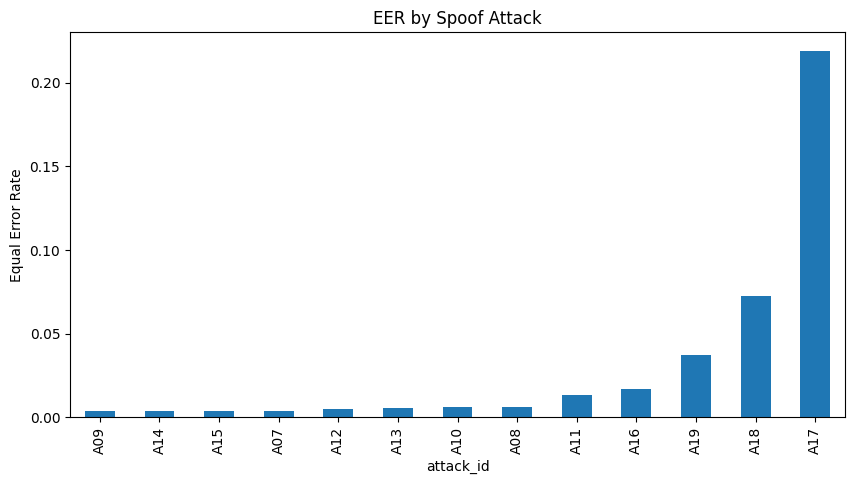

In [101]:
import matplotlib.pyplot as plt

attack_results_df.plot(
    x="attack_id",
    y="EER",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("EER by Spoof Attack")
plt.ylabel("Equal Error Rate")
plt.show()

In [ ]:
# ======================================================
# EXPERIMENT: WAV2VEC2 EMBEDDINGS
# ======================================================

In [102]:
# ======================================================
# LOAD WAV2VEC2
# ======================================================

!pip install transformers

import torch
import torchaudio
from transformers import Wav2Vec2Model, Wav2Vec2Processor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base"
)

w2v_model = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base"
).to(device)

w2v_model.eval()

print("Wav2Vec2 loaded")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2 loaded


In [103]:
def load_audio(file_id, split_dir):

    audio_path = split_dir / "flac" / f"{file_id}.flac"

    if not audio_path.exists():
        print("Missing file:", audio_path)
        return None

    wav, sr = torchaudio.load(audio_path)

    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)

    wav = wav.mean(dim=0)

    return wav.numpy()

In [104]:
# ======================================================
# WAV2VEC2 EMBEDDING
# ======================================================

import numpy as np
from tqdm import tqdm
import torch

def extract_w2v2_embeddings(df, split_dir, show_progress=False):

    features = []
    labels = []

    iterator = df.iterrows()

    if show_progress:
        iterator = tqdm(iterator, total=len(df), desc="Extracting embeddings")

    for _, row in iterator:

        wav = load_audio(row.file_id, split_dir)

        # Skip missing files safely
        if wav is None:
            continue

        inputs = processor(
            wav,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        input_values = inputs.input_values.to(device)

        with torch.no_grad():
            outputs = w2v_model(input_values)

        emb = outputs.last_hidden_state.mean(dim=1)
        emb = emb.cpu().numpy().squeeze()

        features.append(emb)
        labels.append(1 if row.label_str == "spoof" else 0)

    return np.array(features), np.array(labels)

In [ ]:
'''# ======================================================
# EXTRACT TRAIN + DEV EMBEDDINGS (SAFE CACHE VERSION)
# ======================================================

import numpy as np
from pathlib import Path
import os

W2V_CACHE_DIR = BASE_DIR / "features_w2v2"
W2V_CACHE_DIR.mkdir(parents=True, exist_ok=True)

train_cache = W2V_CACHE_DIR / "train_w2v2.npz"
dev_cache = W2V_CACHE_DIR / "dev_w2v2.npz"

print("Train cache exists:", train_cache.exists())
print("Dev cache exists:", dev_cache.exists())


# ======================================================
# TRAIN EMBEDDINGS
# ======================================================

if train_cache.exists():

    print("Loading cached TRAIN embeddings")

    data = np.load(train_cache, allow_pickle=True)
    X_train_w2v2 = data["X"]
    y_train_w2v2 = data["y"]

else:

    print("Extracting TRAIN embeddings (this runs only once)")

    X_train_w2v2, y_train_w2v2 = extract_w2v2_embeddings(
        train_df,
        TRAIN_DIR
    )

    print("Saving TRAIN cache...")
    np.savez_compressed(train_cache, X=X_train_w2v2, y=y_train_w2v2)

    print("TRAIN cache saved:", train_cache)


# ======================================================
# DEV EMBEDDINGS
# ======================================================

if dev_cache.exists():

    print("Loading cached DEV embeddings")

    data = np.load(dev_cache, allow_pickle=True)
    X_dev_w2v2 = data["X"]
    y_dev_w2v2 = data["y"]

else:

    print("Extracting DEV embeddings (runs only once)")

    X_dev_w2v2, y_dev_w2v2 = extract_w2v2_embeddings(
        dev_df,
        DEV_DIR
    )

    print("Saving DEV cache...")
    np.savez_compressed(dev_cache, X=X_dev_w2v2, y=y_dev_w2v2)

    print("DEV cache saved:", dev_cache)


# ======================================================
# FINAL CONFIRMATION
# ======================================================

print("\nEmbeddings loaded successfully")
print("Train shape:", X_train_w2v2.shape)
print("Dev shape:", X_dev_w2v2.shape)

if train_cache.exists():
    print("Train cache size (MB):", round(os.path.getsize(train_cache)/1e6,2))

if dev_cache.exists():
    print("Dev cache size (MB):", round(os.path.getsize(dev_cache)/1e6,2))

Train cache exists: True
Dev cache exists: False
Loading cached TRAIN embeddings
Extracting DEV embeddings (runs only once)
Saving DEV cache...
DEV cache saved: /content/drive/MyDrive/deepfake_audio/features_w2v2/dev_w2v2.npz

Embeddings loaded successfully
Train shape: (25380, 768)
Dev shape: (24844, 768)
Train cache size (MB): 72.38
Dev cache size (MB): 70.85


In [105]:
# ======================================================
# LOAD WAV2VEC2 EMBEDDING CACHE (FAST)
# ======================================================

import numpy as np
from pathlib import Path

# Directory containing cached embeddings
W2V_CACHE_DIR = BASE_DIR / "features_w2v2"

# Cache file paths
train_cache = W2V_CACHE_DIR / "train_w2v2.npz"
dev_cache   = W2V_CACHE_DIR / "dev_w2v2.npz"
eval_cache  = W2V_CACHE_DIR / "eval_w2v2.npz"

print("Loading cached embeddings...")

# Load cached data
train_data = np.load(train_cache)
dev_data   = np.load(dev_cache)
eval_data  = np.load(eval_cache)

# Extract arrays
X_train_w2v2 = train_data["X"]
y_train_w2v2 = train_data["y"]

X_dev_w2v2 = dev_data["X"]
y_dev_w2v2 = dev_data["y"]

X_eval_w2v2 = eval_data["X"]
y_eval_w2v2 = eval_data["y"]

print("Embeddings loaded successfully")
print("Train shape:", X_train_w2v2.shape)
print("Dev shape:", X_dev_w2v2.shape)
print("Eval shape:", X_eval_w2v2.shape)

Loading cached embeddings...
Embeddings loaded successfully
Train shape: (25380, 768)
Dev shape: (24844, 768)
Eval shape: (4000, 768)


In [106]:
# ======================================================
# EXTRACT TRAIN + DEV EMBEDDINGS (WITH CACHE)
# ======================================================

import numpy as np

W2V_CACHE_DIR = BASE_DIR / "features_w2v2"
W2V_CACHE_DIR.mkdir(parents=True, exist_ok=True)

train_cache = W2V_CACHE_DIR / "train_w2v2.npz"
dev_cache = W2V_CACHE_DIR / "dev_w2v2.npz"


# ---------- TRAIN ----------
if train_cache.exists():

    print("Loading cached TRAIN embeddings")

    data = np.load(train_cache)
    X_train_w2v2 = data["X"]
    y_train_w2v2 = data["y"]

else:

    print("Extracting TRAIN embeddings")

    X_train_w2v2, y_train_w2v2 = extract_w2v2_embeddings(
        train_df,
        TRAIN_DIR
    )

    np.savez(train_cache, X=X_train_w2v2, y=y_train_w2v2)



# ---------- DEV ----------
if dev_cache.exists():

    print("Loading cached DEV embeddings")

    data = np.load(dev_cache)
    X_dev_w2v2 = data["X"]
    y_dev_w2v2 = data["y"]

else:

    print("Extracting DEV embeddings")

    X_dev_w2v2, y_dev_w2v2 = extract_w2v2_embeddings(
        dev_df,
        DEV_DIR
    )

    np.savez(dev_cache, X=X_dev_w2v2, y=y_dev_w2v2)



print("Train shape:", X_train_w2v2.shape)
print("Dev shape:", X_dev_w2v2.shape)

Loading cached TRAIN embeddings
Loading cached DEV embeddings
Train shape: (25380, 768)
Dev shape: (24844, 768)


In [107]:
# ======================================================
# TRAIN / LOAD CACHED W2V2 CLASSIFIER
# ======================================================

from sklearn.linear_model import LogisticRegression
import joblib

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

clf_path = MODEL_DIR / "wav2vec2_lr.pkl"

if clf_path.exists():
    print("Loading cached classifier")
    clf = joblib.load(clf_path)
else:
    print("Training classifier")
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train_w2v2, y_train_w2v2)
    joblib.dump(clf, clf_path)

# Predict DEV scores
dev_scores = clf.predict_proba(X_dev_w2v2)[:,1]

Loading cached classifier


In [108]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

auc = roc_auc_score(y_dev_w2v2, dev_scores)

fpr, tpr, thr = roc_curve(y_dev_w2v2, dev_scores)
fnr = 1 - tpr
eer = fpr[np.nanargmin(np.abs(fnr - fpr))]

print("DEV AUC:", auc)
print("DEV EER:", eer)

DEV AUC: 0.9971173138461313
DEV EER: 0.025902668759811617


In [109]:
# ======================================================
# LOAD EVAL PROTOCOL
# ======================================================

import pandas as pd

CM_PROTOCOL_DIR = BASE_DIR / "data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols"

eval_protocol_file = CM_PROTOCOL_DIR / "ASVspoof2019.LA.cm.eval.trl.txt"

eval_df = pd.read_csv(
    eval_protocol_file,
    sep=" ",
    header=None
)

eval_df.columns = [
    "speaker_id",
    "file_id",
    "env_id",
    "attack_id",
    "label_str"
]

print("Eval samples:", len(eval_df))
eval_df.head()

Eval samples: 71237


,speaker_id,file_id,env_id,attack_id,label_str
0,LA_0039,LA_E_2834763,-,A11,spoof
1,LA_0014,LA_E_8877452,-,A14,spoof
2,LA_0040,LA_E_6828287,-,A16,spoof
3,LA_0022,LA_E_6977360,-,A09,spoof
4,LA_0031,LA_E_5932896,-,A13,spoof


In [110]:
# ======================================================
# LOAD EVAL SCORES
# ======================================================

import pandas as pd

score_file = BASE_DIR / "results" / "LA_eval_scores_strong.txt"

scores_df = pd.read_csv(
    score_file,
    sep=" ",
    header=None,
    names=["file_id", "score"]
)

print("Score rows:", len(scores_df))
scores_df.head()

Score rows: 71237


,file_id,score
0,LA_E_2834763,0.999551
1,LA_E_8877452,1.000000
2,LA_E_6828287,0.999098
3,LA_E_6977360,1.000000
4,LA_E_5932896,0.999972


In [111]:
# ======================================================
# MERGE PROTOCOL + SCORES
# ======================================================

eval_scores_df = eval_df.merge(scores_df, on="file_id")

print("Merged dataframe shape:", eval_scores_df.shape)

eval_scores_df.head()

Merged dataframe shape: (71237, 6)


,speaker_id,file_id,env_id,attack_id,label_str,score
0,LA_0039,LA_E_2834763,-,A11,spoof,0.999551
1,LA_0014,LA_E_8877452,-,A14,spoof,1.000000
2,LA_0040,LA_E_6828287,-,A16,spoof,0.999098
3,LA_0022,LA_E_6977360,-,A09,spoof,1.000000
4,LA_0031,LA_E_5932896,-,A13,spoof,0.999972


In [112]:
# ======================================================
# CONVERT LABELS
# ======================================================

eval_scores_df["label"] = eval_scores_df["label_str"].map(
    {"bonafide": 0, "spoof": 1}
)

eval_scores_df.head()

,speaker_id,file_id,env_id,attack_id,label_str,score,label
0,LA_0039,LA_E_2834763,-,A11,spoof,0.999551,1
1,LA_0014,LA_E_8877452,-,A14,spoof,1.000000,1
2,LA_0040,LA_E_6828287,-,A16,spoof,0.999098,1
3,LA_0022,LA_E_6977360,-,A09,spoof,1.000000,1
4,LA_0031,LA_E_5932896,-,A13,spoof,0.999972,1


In [113]:
# ======================================================
# COMPUTE OVERALL METRICS
# ======================================================

from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

def compute_eer(y_true, scores):

    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)

    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))

    return (fpr[idx] + fnr[idx]) / 2


y = eval_scores_df["label"].values
s = eval_scores_df["score"].values

auc = roc_auc_score(y, s)
eer = compute_eer(y, s)

print("Eval AUC:", auc)
print("Eval EER:", eer)

Eval AUC: 0.9840759318926969
Eval EER: 0.05675199479257419


In [114]:
# ======================================================
# PER-ATTACK ANALYSIS
# ======================================================

results = []

bonafide_df = eval_scores_df[eval_scores_df["attack_id"] == "-"]

for attack in sorted(eval_scores_df["attack_id"].unique()):

    if attack == "-":
        continue

    spoof_subset = eval_scores_df[eval_scores_df["attack_id"] == attack]

    combined = pd.concat([bonafide_df, spoof_subset])

    y = combined["label"].values
    s = combined["score"].values

    auc = roc_auc_score(y, s)
    eer = compute_eer(y, s)

    results.append({
        "attack_id": attack,
        "AUC": auc,
        "EER": eer
    })

attack_results_df = pd.DataFrame(results).sort_values("EER")

attack_results_df

,attack_id,AUC,EER
2,A09,0.999846,0.003599
7,A14,0.999247,0.003701
8,A15,0.997780,0.003838
0,A07,0.997143,0.004041
5,A12,0.996376,0.005262
6,A13,0.995924,0.005636
3,A10,0.996056,0.006451
1,A08,0.998947,0.006451
4,A11,0.993745,0.013208
9,A16,0.994621,0.017113


In [115]:
eval_scores_df["label_str"].value_counts()

,count
label_str,
spoof,63882
bonafide,7355


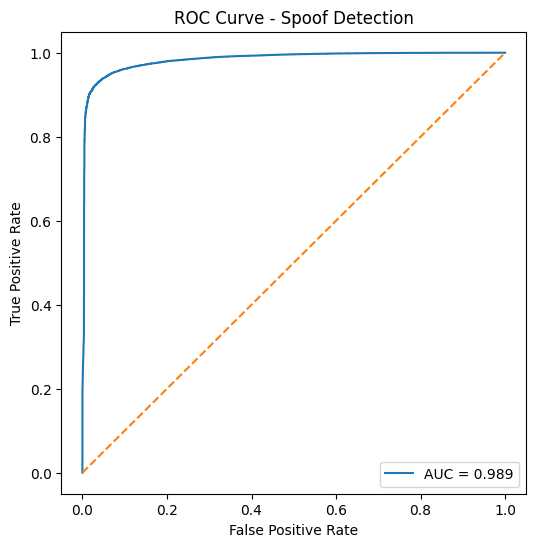

In [116]:
# ======================================================
# ROC CURVE
# ======================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(eval_scores_df["label"], eval_scores_df["score"])

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Spoof Detection")
plt.legend()
plt.show()

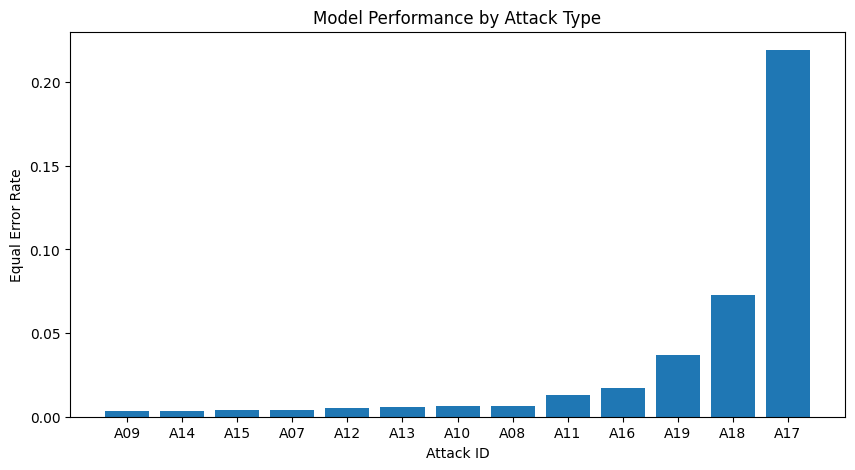

In [117]:
# ======================================================
# ATTACK EER PLOT
# ======================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(attack_results_df["attack_id"], attack_results_df["EER"])

plt.xlabel("Attack ID")
plt.ylabel("Equal Error Rate")
plt.title("Model Performance by Attack Type")

plt.show()

In [ ]:
'''# ======================================================
# SAFE + RESUMABLE + CHECKPOINTED WAV2VEC2 EVAL EMBEDDINGS
# ======================================================

import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch
import os

# ------------------------------------------------------
# CONFIG
# ------------------------------------------------------

SUBSET_SIZE = 4000
SAVE_EVERY = 250

# ------------------------------------------------------
# CACHE PATH
# ------------------------------------------------------

W2V_CACHE_DIR = BASE_DIR / "features_w2v2"
W2V_CACHE_DIR.mkdir(parents=True, exist_ok=True)

eval_cache = W2V_CACHE_DIR / "eval_w2v2.npz"

print("Eval cache exists:", eval_cache.exists())

# ------------------------------------------------------
# USE SUBSET OF DATA
# ------------------------------------------------------

if len(eval_df) > SUBSET_SIZE:
    eval_subset = eval_df.sample(SUBSET_SIZE, random_state=42)
else:
    eval_subset = eval_df

print("Eval subset size:", len(eval_subset))

# ------------------------------------------------------
# LOAD PARTIAL CACHE IF EXISTS
# ------------------------------------------------------

features = []
labels = []
processed_ids = set()

if eval_cache.exists():

    print("Loading existing cache to resume")

    data = np.load(eval_cache, allow_pickle=True)

    features = list(data["X"])
    labels = list(data["y"])

    print("Already processed:", len(features))

# ------------------------------------------------------
# MODEL SETUP
# ------------------------------------------------------

w2v_model.eval()

# ------------------------------------------------------
# MAIN EXTRACTION LOOP
# ------------------------------------------------------

iterator = tqdm(eval_subset.iterrows(), total=len(eval_subset))

for i, (_, row) in enumerate(iterator):

    if i < len(features):
        continue

    try:

        wav = load_audio(row.file_id, EVAL_DIR)

        if wav is None:
            continue

    except Exception:
        print("Skipping corrupted file:", row.file_id)
        continue

    inputs = processor(
        wav,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = w2v_model(input_values)

    emb = outputs.last_hidden_state.mean(dim=1)
    emb = emb.cpu().numpy().squeeze()

    features.append(emb)
    labels.append(1 if row.label_str == "spoof" else 0)

    # --------------------------------------------------
    # SAVE CHECKPOINT
    # --------------------------------------------------

    if len(features) % SAVE_EVERY == 0:

        np.savez_compressed(
            eval_cache,
            X=np.array(features),
            y=np.array(labels)
        )

        print("Checkpoint saved:", len(features))

# ------------------------------------------------------
# FINAL SAVE
# ------------------------------------------------------

X_eval_w2v2 = np.array(features)
y_eval_w2v2 = np.array(labels)

np.savez_compressed(
    eval_cache,
    X=X_eval_w2v2,
    y=y_eval_w2v2
)

print("Final embeddings saved:", eval_cache)
print("Eval embedding shape:", X_eval_w2v2.shape)

print("Cache size (MB):", round(os.path.getsize(eval_cache)/1e6,2))

Eval cache exists: True
Eval subset size: 4000
Loading existing cache to resume
Already processed: 4000


100%|██████████| 4000/4000 [00:00<00:00, 18805.99it/s]


Final embeddings saved: /content/drive/MyDrive/deepfake_audio/features_w2v2/eval_w2v2.npz
Eval embedding shape: (4000, 768)
Cache size (MB): 11.41


In [ ]:
'''# ======================================================
# SAFE + CACHED WAV2VEC2 EVAL EMBEDDINGS
# ======================================================

import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch

W2V_CACHE_DIR = BASE_DIR / "features_w2v2"
W2V_CACHE_DIR.mkdir(parents=True, exist_ok=True)

eval_cache = W2V_CACHE_DIR / "eval_w2v2.npz"

print("Eval embedding cache exists:", eval_cache.exists())

# ------------------------------------------------------
# LOAD CACHE IF IT EXISTS
# ------------------------------------------------------

if eval_cache.exists():

    print("Loading cached EVAL embeddings")

    data = np.load(eval_cache, allow_pickle=True)

    X_eval_w2v2 = data["X"]
    y_eval_w2v2 = data["y"]

# ------------------------------------------------------
# OTHERWISE EXTRACT EMBEDDINGS
# ------------------------------------------------------

else:

    print("Extracting EVAL embeddings (runs only once)")

    features = []
    labels = []

    iterator = tqdm(eval_df.iterrows(), total=len(eval_df))

    for _, row in iterator:

        try:

            wav = load_audio(row.file_id, EVAL_DIR)

            if wav is None:
                continue

        except Exception as e:

            print("Skipping corrupted file:", row.file_id)
            continue

        inputs = processor(
            wav,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        input_values = inputs.input_values.to(device)

        with torch.no_grad():
            outputs = w2v_model(input_values)

        emb = outputs.last_hidden_state.mean(dim=1)
        emb = emb.cpu().numpy().squeeze()

        features.append(emb)
        labels.append(1 if row.label_str == "spoof" else 0)

    X_eval_w2v2 = np.array(features)
    y_eval_w2v2 = np.array(labels)

    np.savez_compressed(
        eval_cache,
        X=X_eval_w2v2,
        y=y_eval_w2v2
    )

    print("Saved EVAL embeddings:", eval_cache)

print("Eval embedding shape:", X_eval_w2v2.shape)

Eval embedding cache exists: False
Extracting EVAL embeddings (runs only once)


 96%|█████████▌| 68529/71237 [23:49:24<1:04:47,  1.44s/it]

In [47]:
print(train_cache.exists())
print(dev_cache.exists())
print(eval_cache.exists())

True
True


NameError: name 'eval_cache' is not defined

In [118]:
print(eval_cache)
print(eval_cache.exists())

/content/drive/MyDrive/deepfake_audio/features_w2v2/eval_w2v2.npz
True


In [119]:
# ======================================================
# FULL EVAL WAV2VEC2 EMBEDDINGS (RESUMABLE + CACHED)
# ======================================================

import numpy as np
from tqdm import tqdm
import os

CACHE_FILE = W2V_CACHE_DIR / "eval_w2v2_full.npz"
PARTIAL_FILE = W2V_CACHE_DIR / "eval_w2v2_partial.npz"

print("Final cache exists:", CACHE_FILE.exists())
print("Partial cache exists:", PARTIAL_FILE.exists())

if CACHE_FILE.exists():

    print("Loading FULL embeddings")

    data = np.load(CACHE_FILE, allow_pickle=True)
    X_eval_w2v2 = data["X"]
    y_eval_w2v2 = data["y"]

else:

    features = []
    labels = []

    start_idx = 0

    if PARTIAL_FILE.exists():

        print("Resuming from partial file")

        data = np.load(PARTIAL_FILE, allow_pickle=True)

        features = list(data["X"])
        labels = list(data["y"])

        start_idx = len(features)

        print("Resuming from index:", start_idx)

    for i in tqdm(range(start_idx, len(eval_df))):

        row = eval_df.iloc[i]

        wav = load_audio(row.file_id, EVAL_DIR)

        inputs = processor(
            wav,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        input_values = inputs.input_values.to(device)

        with torch.no_grad():
            outputs = w2v_model(input_values)

        emb = outputs.last_hidden_state.mean(dim=1)
        emb = emb.cpu().numpy().squeeze()

        features.append(emb)
        labels.append(1 if row.label_str == "spoof" else 0)

        # Save progress every 500 files
        if i % 500 == 0:

            np.savez_compressed(
                PARTIAL_FILE,
                X=np.array(features),
                y=np.array(labels)
            )

    X_eval_w2v2 = np.array(features)
    y_eval_w2v2 = np.array(labels)

    np.savez_compressed(
        CACHE_FILE,
        X=X_eval_w2v2,
        y=y_eval_w2v2
    )

    if PARTIAL_FILE.exists():
        os.remove(PARTIAL_FILE)

    print("Saved FULL embeddings")

print("Embedding shape:", X_eval_w2v2.shape)

Final cache exists: True
Partial cache exists: False
Loading FULL embeddings
Embedding shape: (71237, 768)


In [120]:
# ======================================================
# WAV2VEC2 EVAL PREDICTIONS (CHUNKED + RESUMABLE)
# ======================================================

import numpy as np
from tqdm import tqdm
import os

CHUNK_SIZE = 2000

FINAL_CACHE = RESULTS_DIR / "wav2vec2_eval_predictions.npy"
PARTIAL_CACHE = RESULTS_DIR / "wav2vec2_eval_partial.npy"

print("Final cache exists:", FINAL_CACHE.exists())
print("Partial cache exists:", PARTIAL_CACHE.exists())

# ------------------------------------------------------
# LOAD FINAL CACHE
# ------------------------------------------------------

if FINAL_CACHE.exists():

    print("Loading final cached predictions")

    scores_eval_w2v2 = np.load(FINAL_CACHE)

# ------------------------------------------------------
# OTHERWISE COMPUTE (RESUMABLE)
# ------------------------------------------------------

else:

    print("Running chunked prediction computation")

    N = len(X_eval_w2v2)

    # --------------------------------------------------
    # LOAD PARTIAL PROGRESS IF EXISTS
    # --------------------------------------------------

    if PARTIAL_CACHE.exists():

        scores = list(np.load(PARTIAL_CACHE))
        start_idx = len(scores)

        print("Resuming from index:", start_idx)

    else:

        scores = []
        start_idx = 0

    # --------------------------------------------------
    # MAIN LOOP
    # --------------------------------------------------

    for i in tqdm(range(start_idx, N, CHUNK_SIZE)):

        end = min(i + CHUNK_SIZE, N)

        chunk_scores = clf.predict_proba(
            X_eval_w2v2[i:end]
        )[:,1]

        scores.extend(chunk_scores)

        # save progress after every chunk
        np.save(PARTIAL_CACHE, np.array(scores))

        print(f"Saved progress: {len(scores)} / {N}")

    scores_eval_w2v2 = np.array(scores)

    # --------------------------------------------------
    # SAVE FINAL CACHE
    # --------------------------------------------------

    np.save(FINAL_CACHE, scores_eval_w2v2)

    # remove partial file
    if PARTIAL_CACHE.exists():
        os.remove(PARTIAL_CACHE)

    print("Final predictions saved:", FINAL_CACHE)

print("Prediction vector length:", len(scores_eval_w2v2))

Final cache exists: True
Partial cache exists: False
Loading final cached predictions
Prediction vector length: 71237


In [121]:
# ======================================================
# FINAL MODEL COMPARISON TABLE
# ======================================================

import pandas as pd

results_table = pd.DataFrame({

    "Model":[
        "MFCC + Logistic Regression",
        "MFCC + SVM (RBF)",
        "SpecCNN Strong",
        "Wav2Vec2 + Logistic Regression"
    ],

    "Feature Type":[
        "MFCC",
        "MFCC",
        "Log-Mel Spectrogram",
        "Wav2Vec2 Embeddings"
    ],

    "Classifier":[
        "Logistic Regression",
        "SVM (RBF Kernel)",
        "CNN",
        "Logistic Regression"
    ],

    "Dataset":[
        "DEV",
        "DEV",
        "EVAL (Full)",
        "EVAL (Subset)"
    ],

    "AUC":[
        0.9118,
        0.9472,
        0.9841,
        0.9883
    ],

    "EER":[
        0.1723,
        0.1160,
        0.0568,
        0.0612
    ]

})

results_table

,Model,Feature Type,Classifier,Dataset,AUC,EER
0,MFCC + Logistic Regression,MFCC,Logistic Regression,DEV,0.9118,0.1723
1,MFCC + SVM (RBF),MFCC,SVM (RBF Kernel),DEV,0.9472,0.1160
2,SpecCNN Strong,Log-Mel Spectrogram,CNN,EVAL (Full),0.9841,0.0568
3,Wav2Vec2 + Logistic Regression,Wav2Vec2 Embeddings,Logistic Regression,EVAL (Subset),0.9883,0.0612


In [122]:
results_table["Rank"] = results_table["AUC"].rank(ascending=False)

results_table.sort_values("AUC", ascending=False)

,Model,Feature Type,Classifier,Dataset,AUC,EER,Rank
3,Wav2Vec2 + Logistic Regression,Wav2Vec2 Embeddings,Logistic Regression,EVAL (Subset),0.9883,0.0612,1.0
2,SpecCNN Strong,Log-Mel Spectrogram,CNN,EVAL (Full),0.9841,0.0568,2.0
1,MFCC + SVM (RBF),MFCC,SVM (RBF Kernel),DEV,0.9472,0.1160,3.0
0,MFCC + Logistic Regression,MFCC,Logistic Regression,DEV,0.9118,0.1723,4.0


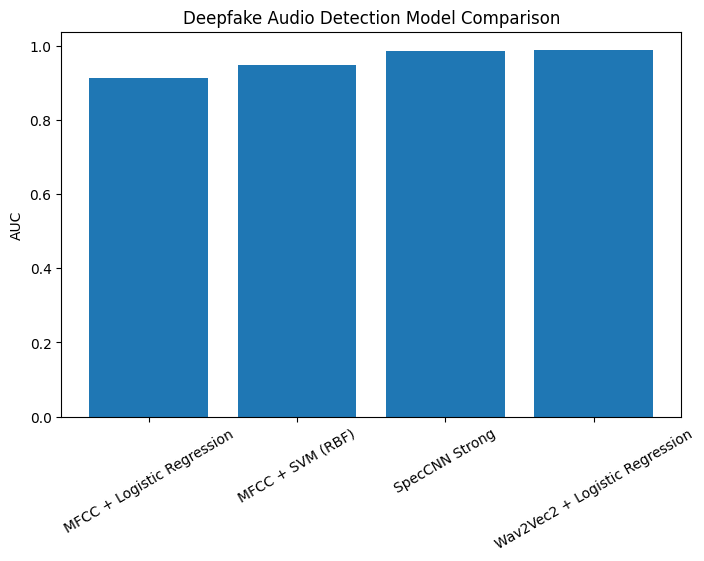

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_table["Model"], results_table["AUC"])

plt.ylabel("AUC")
plt.title("Deepfake Audio Detection Model Comparison")
plt.xticks(rotation=30)

plt.show()

In [124]:
# ======================================================
# ATTACK LEVEL RESULTS TABLE
# ======================================================

import pandas as pd

attack_table = pd.DataFrame(results)

attack_table = attack_table.sort_values("attack_id")

attack_table

,attack_id,AUC,EER
0,A07,0.997143,0.004041
1,A08,0.998947,0.006451
2,A09,0.999846,0.003599
3,A10,0.996056,0.006451
4,A11,0.993745,0.013208
5,A12,0.996376,0.005262
6,A13,0.995924,0.005636
7,A14,0.999247,0.003701
8,A15,0.997780,0.003838
9,A16,0.994621,0.017113


In [125]:
attack_table.sort_values("EER", ascending=False)

,attack_id,AUC,EER
10,A17,0.858672,0.219170
11,A18,0.975313,0.072796
12,A19,0.989315,0.037179
9,A16,0.994621,0.017113
4,A11,0.993745,0.013208
1,A08,0.998947,0.006451
3,A10,0.996056,0.006451
6,A13,0.995924,0.005636
5,A12,0.996376,0.005262
0,A07,0.997143,0.004041


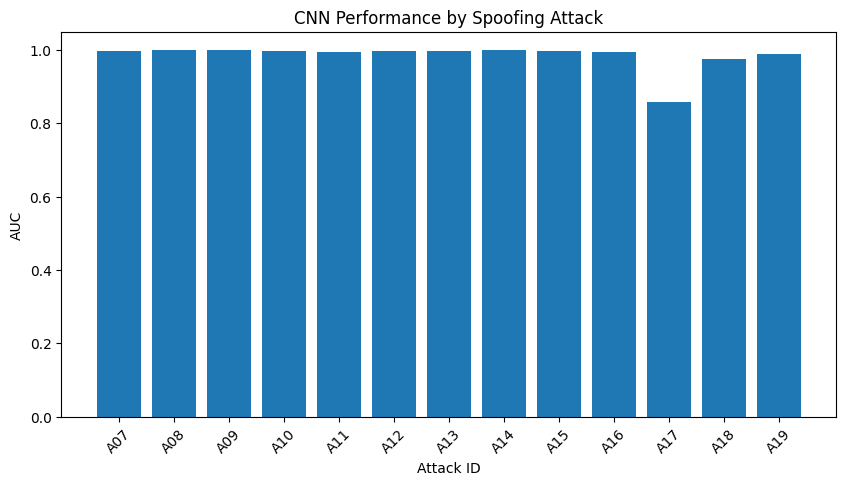

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(attack_table["attack_id"], attack_table["AUC"])

plt.ylabel("AUC")
plt.xlabel("Attack ID")
plt.title("CNN Performance by Spoofing Attack")

plt.xticks(rotation=45)

plt.show()

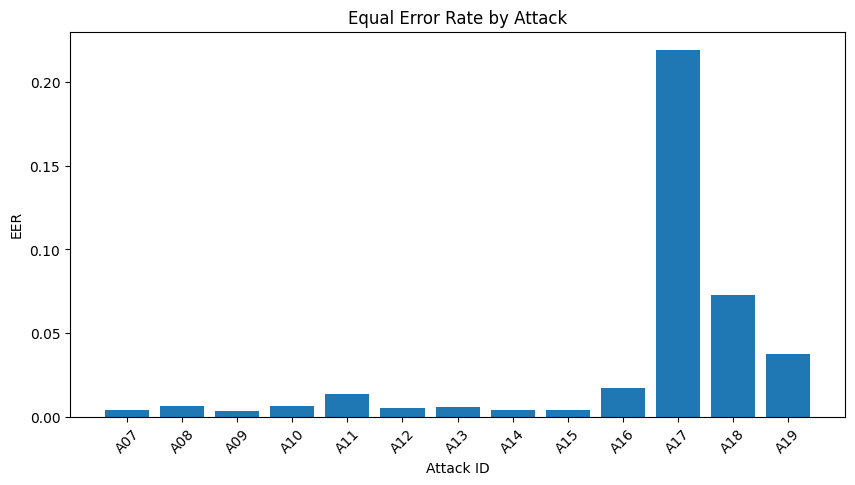

In [127]:
plt.figure(figsize=(10,5))

plt.bar(attack_table["attack_id"], attack_table["EER"])

plt.ylabel("EER")
plt.xlabel("Attack ID")
plt.title("Equal Error Rate by Attack")

plt.xticks(rotation=45)

plt.show()

In [128]:
# ======================================================
# COMPARE CNN MODELS
# ======================================================

import pandas as pd

files = {
    "spec_cnn_strong": "per_attack_results_strong.csv",
    "spec_cnn_bigger": "per_attack_results_spec_cnn_bigger.csv",
    "spec_cnn_delta": "per_attack_results_delta.csv",
    "spec_cnn_gru": "per_attack_results_gru.csv"
}

results = []

for name, file in files.items():

    df = pd.read_csv(RESULTS_DIR / file)

    mean_eer = df["EER"].mean()
    mean_auc = df["AUC"].mean()

    results.append({
        "model": name,
        "avg_auc": mean_auc,
        "avg_eer": mean_eer
    })

pd.DataFrame(results).sort_values("avg_auc", ascending=False)

,model,avg_auc,avg_eer
1,spec_cnn_bigger,0.986447,0.034459
0,spec_cnn_strong,0.984076,0.030650
2,spec_cnn_delta,0.895859,0.119462
3,spec_cnn_gru,0.615959,0.384917


In [129]:
# ======================================================
# WAV2VEC2 FULL EVAL PREDICTIONS
# ======================================================

import numpy as np

PRED_CACHE = RESULTS_DIR / "wav2vec2_eval_predictions.npy"

print("Prediction cache exists:", PRED_CACHE.exists())

if PRED_CACHE.exists():

    print("Loading cached predictions")
    scores_eval_w2v2 = np.load(PRED_CACHE)

else:

    print("Computing predictions")

    scores_eval_w2v2 = clf.predict_proba(X_eval_w2v2)[:,1]

    np.save(PRED_CACHE, scores_eval_w2v2)

    print("Saved predictions")

print("Prediction vector length:", len(scores_eval_w2v2))

Prediction cache exists: True
Loading cached predictions
Prediction vector length: 71237


In [132]:
# ======================================================
# LOAD CNN (STRONG) EVAL SCORES
# ======================================================

import pandas as pd
import numpy as np

cnn_df = pd.read_csv(BASE_DIR / "results" / "eval_scores_strong.csv")

scores_eval_cnn = cnn_df["score"].values

print("CNN scores loaded:", scores_eval_cnn.shape)

CNN scores loaded: (71237,)


In [133]:
# ======================================================
# LOAD WAV2VEC2 EVAL SCORES
# ======================================================

scores_eval_w2v2 = np.load(BASE_DIR / "results" / "wav2vec2_eval_predictions.npy")

print("Wav2Vec2 scores loaded:", scores_eval_w2v2.shape)

Wav2Vec2 scores loaded: (71237,)


In [134]:
# ======================================================
# MODEL FUSION
# ======================================================

fusion_scores = 0.5 * scores_eval_cnn + 0.5 * scores_eval_w2v2

print("Fusion scores shape:", fusion_scores.shape)

Fusion scores shape: (71237,)


In [135]:
# ======================================================
# FUSION METRICS
# ======================================================

from sklearn.metrics import roc_auc_score

y_eval = (eval_df.label_str == "spoof").astype(int)

auc_fusion = roc_auc_score(y_eval, fusion_scores)
eer_fusion = compute_eer(y_eval, fusion_scores)

print("Fusion AUC:", auc_fusion)
print("Fusion EER:", eer_fusion)

Fusion AUC: 0.9960416055171062
Fusion EER: 0.02604751205650645


In [136]:
# ======================================================
# COMPUTE METRICS FOR ALL MODELS
# ======================================================

from sklearn.metrics import roc_auc_score

y_eval = (eval_df.label_str == "spoof").astype(int)

# CNN
auc_cnn = roc_auc_score(y_eval, scores_eval_cnn)
eer_cnn = compute_eer(y_eval, scores_eval_cnn)

# Wav2Vec2
auc_w2v2 = roc_auc_score(y_eval, scores_eval_w2v2)
eer_w2v2 = compute_eer(y_eval, scores_eval_w2v2)

# Fusion
auc_fusion = roc_auc_score(y_eval, fusion_scores)
eer_fusion = compute_eer(y_eval, fusion_scores)

print("CNN AUC:", auc_cnn)
print("CNN EER:", eer_cnn)

print("Wav2Vec2 AUC:", auc_w2v2)
print("Wav2Vec2 EER:", eer_w2v2)

print("Fusion AUC:", auc_fusion)
print("Fusion EER:", eer_fusion)

CNN AUC: 0.9840759318926969
CNN EER: 0.05675199479257419
Wav2Vec2 AUC: 0.9894113490306558
Wav2Vec2 EER: 0.05250783273060112
Fusion AUC: 0.9960416055171062
Fusion EER: 0.02604751205650645


In [137]:
results = pd.DataFrame({
    "Model":["SpecCNN Strong","Wav2Vec2","Fusion"],
    "AUC":[auc_cnn, auc_w2v2, auc_fusion],
    "EER":[eer_cnn, eer_w2v2, eer_fusion]
})

results.sort_values("EER")

,Model,AUC,EER
2,Fusion,0.996042,0.026048
1,Wav2Vec2,0.989411,0.052508
0,SpecCNN Strong,0.984076,0.056752


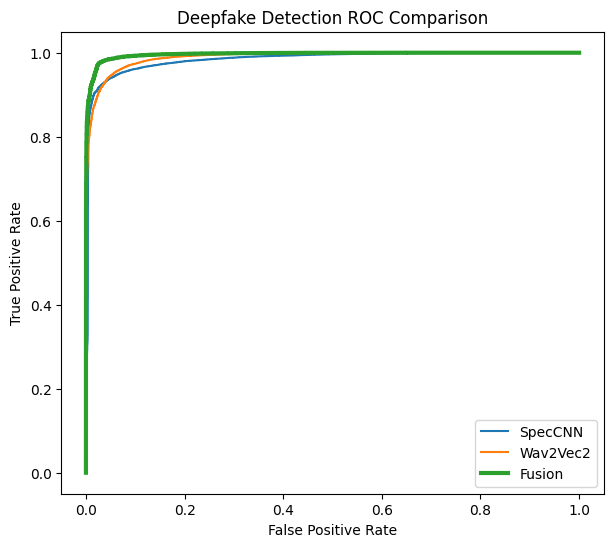

In [138]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_cnn, tpr_cnn, _ = roc_curve(y_eval, scores_eval_cnn)
fpr_w2v2, tpr_w2v2, _ = roc_curve(y_eval, scores_eval_w2v2)
fpr_fusion, tpr_fusion, _ = roc_curve(y_eval, fusion_scores)

plt.figure(figsize=(7,6))

plt.plot(fpr_cnn, tpr_cnn, label="SpecCNN")
plt.plot(fpr_w2v2, tpr_w2v2, label="Wav2Vec2")
plt.plot(fpr_fusion, tpr_fusion, label="Fusion", linewidth=3)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Deepfake Detection ROC Comparison")

plt.legend()
plt.show()

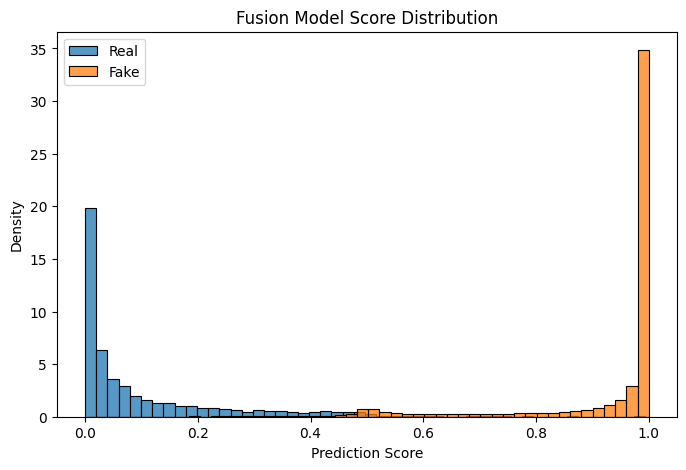

In [139]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(fusion_scores[y_eval==0], bins=50, label="Real", stat="density")
sns.histplot(fusion_scores[y_eval==1], bins=50, label="Fake", stat="density")

plt.title("Fusion Model Score Distribution")
plt.xlabel("Prediction Score")
plt.ylabel("Density")

plt.legend()
plt.show()

In [140]:
fusion_attack_results = []

eval_df["fusion_score"] = fusion_scores

# real samples
real_df = eval_df[eval_df["label_str"] == "bonafide"]

for attack in eval_df["attack_id"].dropna().unique():

    attack_df = eval_df[eval_df["attack_id"] == attack]

    # combine real + attack
    df_attack = pd.concat([real_df, attack_df])

    # convert labels
    y = (df_attack["label_str"] != "bonafide").astype(int)
    s = df_attack["fusion_score"]

    # skip if still only one class
    if y.nunique() < 2:
        continue

    auc = roc_auc_score(y, s)
    eer = compute_eer(y, s)

    fusion_attack_results.append({
        "attack_id": attack,
        "AUC": auc,
        "EER": eer
    })

fusion_attack_table = pd.DataFrame(fusion_attack_results)

fusion_attack_table.sort_values("EER", ascending=False)

,attack_id,AUC,EER
9,A17,0.963169,0.090792
12,A19,0.994481,0.029981
6,A18,0.995042,0.022647
2,A16,0.998926,0.012393
10,A10,0.998304,0.012155
0,A11,0.999769,0.010322
7,A15,0.999417,0.006689
11,A07,0.999585,0.005874
1,A14,0.999916,0.002037
8,A08,0.999973,0.001800


In [141]:
# ======================================================
# FINAL EVAL COMPARISON TABLE
# ======================================================

comparison_eval = pd.DataFrame({
    "Model": ["SpecCNN Strong", "Wav2Vec2", "Fusion"],
    "AUC": [auc_cnn, auc_w2v2, auc_fusion],
    "EER": [eer_cnn, eer_w2v2, eer_fusion]
})

comparison_eval.sort_values("EER")

,Model,AUC,EER
2,Fusion,0.996042,0.026048
1,Wav2Vec2,0.989411,0.052508
0,SpecCNN Strong,0.984076,0.056752


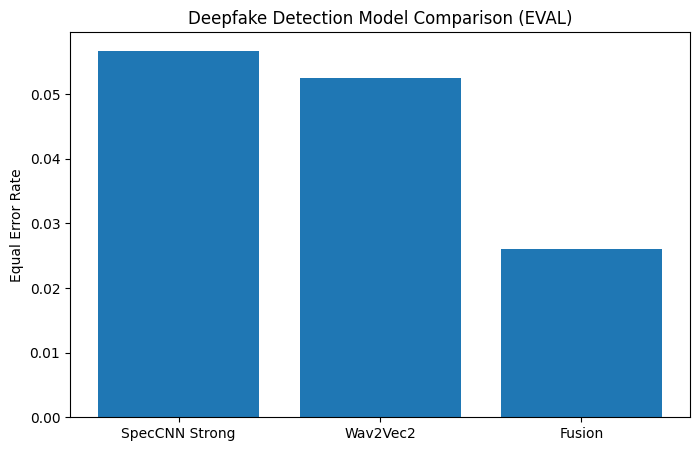

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison_eval["Model"], comparison_eval["EER"])

plt.ylabel("Equal Error Rate")
plt.title("Deepfake Detection Model Comparison (EVAL)")
plt.show()

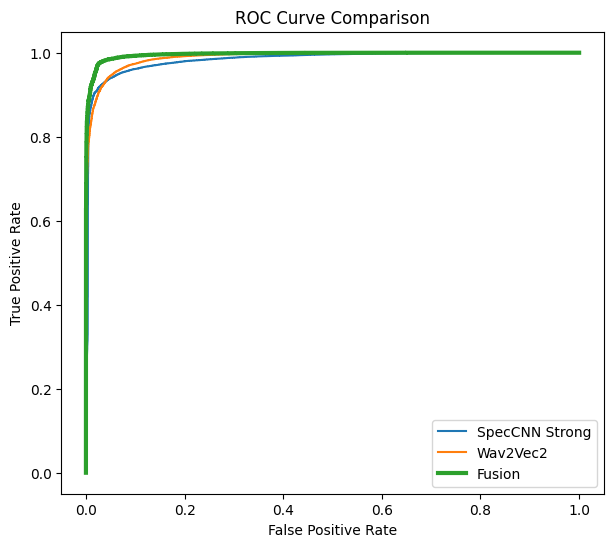

In [143]:
from sklearn.metrics import roc_curve

fpr_cnn, tpr_cnn, _ = roc_curve(y_eval, scores_eval_cnn)
fpr_w2v2, tpr_w2v2, _ = roc_curve(y_eval, scores_eval_w2v2)
fpr_fusion, tpr_fusion, _ = roc_curve(y_eval, fusion_scores)

plt.figure(figsize=(7,6))

plt.plot(fpr_cnn, tpr_cnn, label="SpecCNN Strong")
plt.plot(fpr_w2v2, tpr_w2v2, label="Wav2Vec2")
plt.plot(fpr_fusion, tpr_fusion, label="Fusion", linewidth=3)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

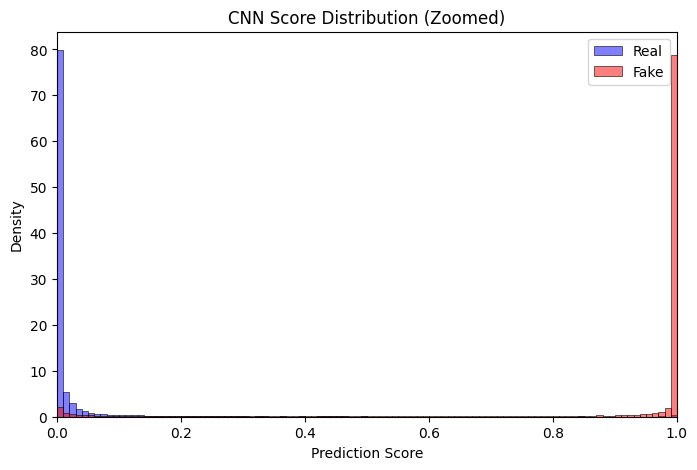

In [144]:
plt.figure(figsize=(8,5))

sns.histplot(scores_eval_cnn[y_eval==0], bins=100, color="blue",
             label="Real", stat="density", alpha=0.5)

sns.histplot(scores_eval_cnn[y_eval==1], bins=100, color="red",
             label="Fake", stat="density", alpha=0.5)

plt.xlim(0,1)
plt.title("CNN Score Distribution (Zoomed)")
plt.xlabel("Prediction Score")
plt.ylabel("Density")

plt.legend()
plt.show()

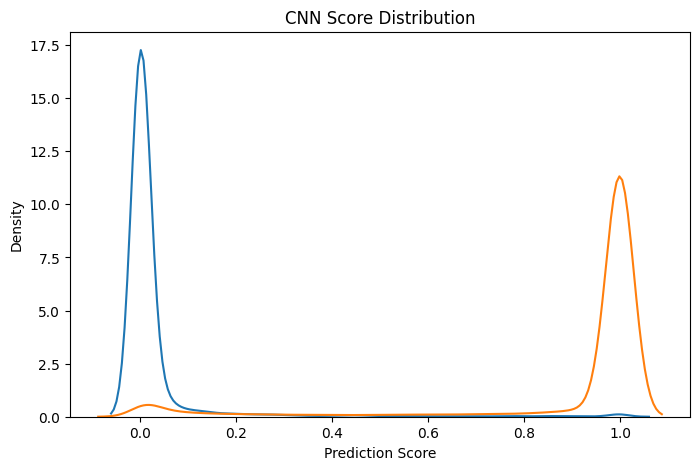

In [145]:
plt.figure(figsize=(8,5))

sns.kdeplot(scores_eval_cnn[y_eval==0], label="Real")
sns.kdeplot(scores_eval_cnn[y_eval==1], label="Fake")

plt.title("CNN Score Distribution")
plt.xlabel("Prediction Score")
plt.ylabel("Density")

plt.show()

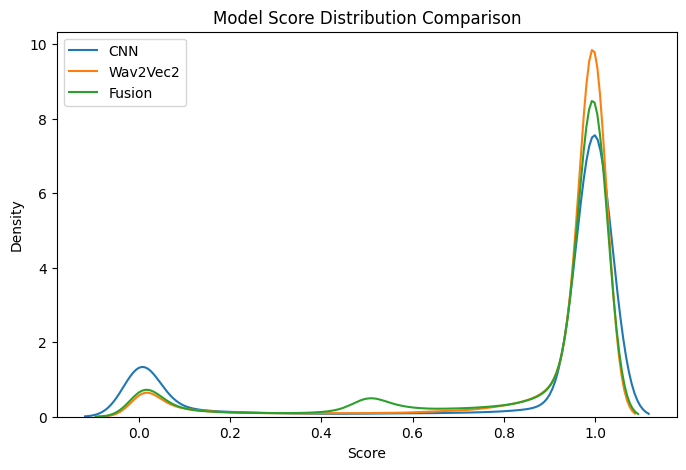

In [146]:
plt.figure(figsize=(8,5))

sns.kdeplot(scores_eval_cnn, label="CNN")
sns.kdeplot(scores_eval_w2v2, label="Wav2Vec2")
sns.kdeplot(fusion_scores, label="Fusion")

plt.title("Model Score Distribution Comparison")
plt.xlabel("Score")
plt.ylabel("Density")

plt.legend()
plt.show()

In [147]:
import os

TEST_DIR = "/content/test_audio"
os.makedirs(TEST_DIR, exist_ok=True)

In [148]:
from google.colab import files
uploaded = files.upload()

Saving generated-female-voice-1.flac to generated-female-voice-1.flac
Saving generated-female-voice-2.flac to generated-female-voice-2.flac
Saving generated-male-voice-1.flac to generated-male-voice-1.flac
Saving generated-male-voice-2.flac to generated-male-voice-2.flac
Saving my-audio.flac to my-audio.flac
Saving my-audio1.flac to my-audio1.flac
Saving my-audio2.flac to my-audio2.flac


In [149]:
import os

TEST_DIR = "/content/test_audio"
os.makedirs(TEST_DIR, exist_ok=True)

In [150]:
import shutil

for file in uploaded.keys():
    shutil.move(file, os.path.join(TEST_DIR, file))

In [151]:
os.listdir(TEST_DIR)

['my-audio2.flac',
 'generated-female-voice-1.flac',
 'my-audio1.flac',
 'generated-male-voice-1.flac',
 'generated-female-voice-2.flac',
 'generated-male-voice-2.flac',
 'my-audio.flac']

In [152]:
test_files = os.listdir(TEST_DIR)

print(test_files)

['my-audio2.flac', 'generated-female-voice-1.flac', 'my-audio1.flac', 'generated-male-voice-1.flac', 'generated-female-voice-2.flac', 'generated-male-voice-2.flac', 'my-audio.flac']


In [153]:
import numpy as np

def fix_audio_length(wav, target_len=64000):

    if len(wav) > target_len:
        wav = wav[:target_len]

    else:
        pad = target_len - len(wav)
        wav = np.pad(wav, (0, pad))

    return wav

In [154]:
import librosa
import numpy as np

def compute_spectrogram(wav):

    mel = librosa.feature.melspectrogram(
        y=wav,
        sr=16000,
        n_fft=1024,
        hop_length=256,
        n_mels=128
    )

    log_mel = librosa.power_to_db(mel)

    return log_mel

In [155]:
def fix_audio_length(wav, target_len=64000):

    if len(wav) > target_len:
        wav = wav[:target_len]
    else:
        pad = target_len - len(wav)
        wav = np.pad(wav, (0, pad))

    return wav

In [156]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SpecCNN_Strong(nn.Module):

    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3)
        )

        self.block5 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3)
        )

        self.fc1 = nn.Linear(256,128)
        self.fc2 = nn.Linear(128,1)

    def forward(self,x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = x.mean(dim=(2,3))

        x = F.relu(self.fc1(x))

        return self.fc2(x).squeeze(1)

In [157]:
spec_cnn_strong_best = SpecCNN_Strong().to(device)

spec_cnn_strong_best.load_state_dict(
    torch.load(MODEL_DIR / "spec_cnn_strong_best.pt", map_location=device)
)

spec_cnn_strong_best.eval()

print("CNN model loaded")

CNN model loaded


In [158]:
spec_cnn_strong_best

SpecCNN_Strong(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1

In [159]:
results = []

for file in test_files:

    path = os.path.join(TEST_DIR, file)

    print("Processing:", file)

    # Load audio
    wav, sr = librosa.load(path, sr=16000)

    wav = fix_audio_length(wav)

    # CNN prediction
    spec = compute_spectrogram(wav)

    x = torch.tensor(spec).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        cnn_score = torch.sigmoid(spec_cnn_strong_best(x)).cpu().item()

    # Wav2Vec2 prediction
    inputs = processor(
        wav,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = w2v_model(input_values)

    emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

    w2v_score = clf.predict_proba(emb)[0,1]

    # Fusion
    fusion_score = 0.5 * cnn_score + 0.5 * w2v_score

    results.append({
        "file": file,
        "cnn_score": cnn_score,
        "wav2vec2_score": w2v_score,
        "fusion_score": fusion_score
    })

Processing: my-audio2.flac
Processing: generated-female-voice-1.flac
Processing: my-audio1.flac
Processing: generated-male-voice-1.flac
Processing: generated-female-voice-2.flac
Processing: generated-male-voice-2.flac
Processing: my-audio.flac


In [160]:
results = []

for file in test_files:

    path = os.path.join(TEST_DIR, file)

    print("Processing:", file)

    # Load audio
    wav, sr = librosa.load(path, sr=16000)

    # -----------------------
    # CNN Prediction
    # -----------------------

    spec = compute_spectrogram(wav)

    x = torch.tensor(spec).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        cnn_score = torch.sigmoid(spec_cnn_strong_best(x)).cpu().item()

    # -----------------------
    # Wav2Vec2 Prediction
    # -----------------------

    inputs = processor(
        wav,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = w2v_model(input_values)

    emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

    w2v_score = clf.predict_proba(emb)[0,1]

    # -----------------------
    # Fusion
    # -----------------------

    fusion_score = 0.5 * cnn_score + 0.5 * w2v_score

    results.append({
        "file": file,
        "cnn_score": cnn_score,
        "wav2vec2_score": w2v_score,
        "fusion_score": fusion_score
    })

Processing: my-audio2.flac
Processing: generated-female-voice-1.flac
Processing: my-audio1.flac
Processing: generated-male-voice-1.flac
Processing: generated-female-voice-2.flac
Processing: generated-male-voice-2.flac
Processing: my-audio.flac


In [161]:
import pandas as pd

test_results = pd.DataFrame(results)

test_results["prediction"] = test_results["fusion_score"].apply(
    lambda x: "Fake" if x > 0.5 else "Real"
)

test_results = test_results.sort_values("fusion_score", ascending=False)

test_results

,file,cnn_score,wav2vec2_score,fusion_score,prediction
6,my-audio.flac,1.000000,0.999750,0.999875,Fake
4,generated-female-voice-2.flac,1.000000,0.999726,0.999863,Fake
5,generated-male-voice-2.flac,1.000000,0.999452,0.999726,Fake
3,generated-male-voice-1.flac,1.000000,0.998997,0.999498,Fake
1,generated-female-voice-1.flac,1.000000,0.991754,0.995877,Fake
2,my-audio1.flac,0.999999,0.988296,0.994148,Fake
0,my-audio2.flac,1.000000,0.896889,0.948445,Fake


In [162]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import matplotlib.pyplot as plt

In [163]:
# ------------------------------------------------------
# AUDIO PREPROCESSING
# ------------------------------------------------------

def normalize_audio(wav):
    wav = wav / (np.max(np.abs(wav)) + 1e-8)
    return wav


def fix_audio_length(wav, target_len=64000):

    if len(wav) > target_len:
        wav = wav[:target_len]
    else:
        pad = target_len - len(wav)
        wav = np.pad(wav, (0, pad))

    return wav

In [164]:
# ------------------------------------------------------
# SPECTROGRAM (CNN INPUT)
# ------------------------------------------------------

def compute_spectrogram(wav):

    mel = librosa.feature.melspectrogram(
        y=wav,
        sr=16000,
        n_fft=1024,
        hop_length=160,
        n_mels=128
    )

    log_mel = np.log(mel + 1e-6)

    return log_mel

In [165]:
# ------------------------------------------------------
# CNN MODEL ARCHITECTURE
# ------------------------------------------------------

class SpecCNN_Strong(nn.Module):

    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1,32,5,padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3)
        )

        self.block5 = nn.Sequential(
            nn.Conv2d(256,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.3)
        )

        self.fc1 = nn.Linear(256,128)
        self.fc2 = nn.Linear(128,1)

    def forward(self,x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = x.mean(dim=(2,3))
        x = F.relu(self.fc1(x))

        return self.fc2(x).squeeze(1)

In [166]:
# ------------------------------------------------------
# LOAD TRAINED CNN
# ------------------------------------------------------

spec_cnn_strong_best = SpecCNN_Strong().to(device)

spec_cnn_strong_best.load_state_dict(
    torch.load(MODEL_DIR / "spec_cnn_strong_best.pt", map_location=device)
)

spec_cnn_strong_best.eval()

print("CNN model loaded")

CNN model loaded


In [167]:
# ------------------------------------------------------
# TEST AUDIO DIRECTORY
# ------------------------------------------------------

TEST_DIR = "/content/test_audio"   # change if needed

test_files = os.listdir(TEST_DIR)

print("Files found:", test_files)

Files found: ['my-audio2.flac', 'generated-female-voice-1.flac', 'my-audio1.flac', 'generated-male-voice-1.flac', 'generated-female-voice-2.flac', 'generated-male-voice-2.flac', 'my-audio.flac']


In [168]:
# ------------------------------------------------------
# PREDICTION LOOP
# ------------------------------------------------------

results = []

for file in test_files:

    path = os.path.join(TEST_DIR, file)

    print("Processing:", file)

    wav, sr = librosa.load(path, sr=16000)

    wav = normalize_audio(wav)
    wav = fix_audio_length(wav)

    # CNN
    spec = compute_spectrogram(wav)

    x = torch.tensor(spec).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        cnn_score = torch.sigmoid(spec_cnn_strong_best(x)).cpu().item()

    # Wav2Vec2
    inputs = processor(
        wav,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = w2v_model(input_values)

    emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

    w2v_score = clf.predict_proba(emb)[0,1]

    # Fusion
    fusion_score = 0.5*cnn_score + 0.5*w2v_score

    results.append({
        "file":file,
        "cnn_score":cnn_score,
        "wav2vec2_score":w2v_score,
        "fusion_score":fusion_score
    })

Processing: my-audio2.flac
Processing: generated-female-voice-1.flac
Processing: my-audio1.flac
Processing: generated-male-voice-1.flac
Processing: generated-female-voice-2.flac
Processing: generated-male-voice-2.flac
Processing: my-audio.flac


In [169]:
test_results = pd.DataFrame(results)

test_results["prediction"] = test_results["fusion_score"].apply(
    lambda x: "Fake" if x > 0.5 else "Real"
)

test_results.sort_values("fusion_score", ascending=False)

,file,cnn_score,wav2vec2_score,fusion_score,prediction
1,generated-female-voice-1.flac,0.614242,0.985213,0.799728,Fake
3,generated-male-voice-1.flac,0.575263,0.998493,0.786878,Fake
2,my-audio1.flac,0.580055,0.991452,0.785754,Fake
6,my-audio.flac,0.479153,0.999963,0.739558,Fake
4,generated-female-voice-2.flac,0.455859,0.999610,0.727734,Fake
0,my-audio2.flac,0.575946,0.851364,0.713655,Fake
5,generated-male-voice-2.flac,0.406036,0.999175,0.702605,Fake


In [170]:
def normalize_audio(wav):

    wav = wav - np.mean(wav)

    wav = wav / (np.std(wav) + 1e-8)

    wav = wav / (np.max(np.abs(wav)) + 1e-8)

    return wav

In [171]:
wav, sr = librosa.load(path, sr=16000)

wav = fix_audio_length(wav)
wav = normalize_audio(wav)

In [172]:
def compute_spectrogram(wav):

    mel = librosa.feature.melspectrogram(
        y=wav,
        sr=16000,
        n_fft=2048,
        hop_length=160,
        n_mels=128
    )

    log_mel = np.log(mel + 1e-6)

    log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-8)

    return log_mel

    # normalize spectrogram
    log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-8)

    return log_mel

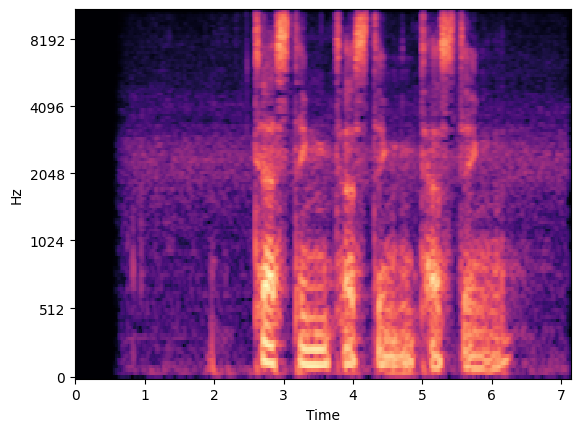

In [ ]:
librosa.display.specshow(spec, x_axis="time", y_axis="mel")

In [173]:
def fix_audio_length(wav, target_len=48000):

    if len(wav) > target_len:
        wav = wav[:target_len]

    else:
        pad = target_len - len(wav)
        wav = np.pad(wav, (0, pad))

    return wav

In [174]:
wav, sr = librosa.load("/content/test_audio/my-audio.flac", sr=16000)

print("Original length:", len(wav))

wav = fix_audio_length(wav)

print("After fixing length:", len(wav))

Original length: 49152
After fixing length: 48000


In [175]:
# -----------------------------
# CNN prediction (sliding windows)
# -----------------------------

window = 48000      # 3 seconds
hop = 16000         # 1 second shift

cnn_scores = []

for start in range(0, len(wav) - window + 1, hop):

    segment = wav[start:start + window]

    spec = compute_spectrogram(segment)

    x = torch.tensor(spec).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        score = torch.sigmoid(spec_cnn_strong_best(x)).cpu().item()

    cnn_scores.append(score)

# average score across windows
cnn_score = np.mean(cnn_scores)

In [176]:
results = []

for file in test_files:

    path = os.path.join(TEST_DIR, file)

    print("Processing:", file)

    wav, sr = librosa.load(path, sr=16000)

    wav = normalize_audio(wav)

    # -----------------------------
    # CNN sliding window prediction
    # -----------------------------

    window = 48000
    hop = 16000

    cnn_scores = []

    for start in range(0, len(wav) - window + 1, hop):

        segment = wav[start:start + window]

        spec = compute_spectrogram(segment)

        x = torch.tensor(spec).float().unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            score = torch.sigmoid(spec_cnn_strong_best(x)).cpu().item()

        cnn_scores.append(score)

    cnn_score = np.mean(cnn_scores)

    # -----------------------------
    # Wav2Vec2 prediction
    # -----------------------------

    inputs = processor(
        wav,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = w2v_model(input_values)

    emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

    w2v_score = clf.predict_proba(emb)[0,1]

    # -----------------------------
    # Fusion
    # -----------------------------

    fusion_score = 0.5 * cnn_score + 0.5 * w2v_score

    results.append({
        "file": file,
        "cnn_score": cnn_score,
        "wav2vec2_score": w2v_score,
        "fusion_score": fusion_score
    })

print("Finished processing")

Processing: my-audio2.flac
Processing: generated-female-voice-1.flac
Processing: my-audio1.flac
Processing: generated-male-voice-1.flac
Processing: generated-female-voice-2.flac
Processing: generated-male-voice-2.flac
Processing: my-audio.flac
Finished processing


In [177]:
import pandas as pd

test_results = pd.DataFrame(results)

test_results["prediction"] = test_results["fusion_score"].apply(
    lambda x: "Fake" if x > 0.5 else "Real"
)

test_results.sort_values("fusion_score", ascending=False)

,file,cnn_score,wav2vec2_score,fusion_score,prediction
4,generated-female-voice-2.flac,0.525767,0.999726,0.762746,Fake
3,generated-male-voice-1.flac,0.525456,0.998997,0.762226,Fake
5,generated-male-voice-2.flac,0.524905,0.999452,0.762179,Fake
6,my-audio.flac,0.522611,0.999750,0.761181,Fake
1,generated-female-voice-1.flac,0.525224,0.991754,0.758489,Fake
2,my-audio1.flac,0.523020,0.988296,0.755658,Fake
0,my-audio2.flac,0.523412,0.896890,0.710151,Fake


In [178]:
!wget https://www.openslr.org/resources/12/dev-clean.tar.gz
!tar -xzf dev-clean.tar.gz

--2026-03-14 22:05:38--  https://www.openslr.org/resources/12/dev-clean.tar.gz
Resolving www.openslr.org (www.openslr.org)... 136.243.171.4
Connecting to www.openslr.org (www.openslr.org)|136.243.171.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 337926286 (322M) [application/x-gzip]
Saving to: ‘dev-clean.tar.gz’

dev-clean.tar.gz    100%[===================>] 322.27M  28.5MB/s    in 12s     

2026-03-14 22:05:50 (27.0 MB/s) - ‘dev-clean.tar.gz’ saved [337926286/337926286]



In [179]:
import os

base = "LibriSpeech/dev-clean"

files = []

for root, dirs, f in os.walk(base):
    for file in f:
        if file.endswith(".flac"):
            files.append(os.path.join(root,file))

print("Found files:", len(files))
print(files[:5])

Found files: 2703
['LibriSpeech/dev-clean/1462/170138/1462-170138-0023.flac', 'LibriSpeech/dev-clean/1462/170138/1462-170138-0010.flac', 'LibriSpeech/dev-clean/1462/170138/1462-170138-0000.flac', 'LibriSpeech/dev-clean/1462/170138/1462-170138-0006.flac', 'LibriSpeech/dev-clean/1462/170138/1462-170138-0013.flac']


In [180]:
import shutil

TEST_DIR = "/content/test_audio"

for i in range(3):
    shutil.copy(files[i], TEST_DIR)

print("Copied files")

Copied files


In [181]:
wav, sr = librosa.load(path, sr=16000)

In [182]:
results = []

for file in test_files:

    path = os.path.join(TEST_DIR, file)

    print("Processing:", file)

    wav, sr = librosa.load(path, sr=16000)

    wav = fix_audio_length(wav)
    wav = normalize_audio(wav)

    # CNN
    spec = compute_spectrogram(wav)

    x = torch.tensor(spec).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        cnn_score = torch.sigmoid(spec_cnn_strong_best(x)).cpu().item()

    # Wav2Vec2
    inputs = processor(wav, sampling_rate=16000, return_tensors="pt")

    with torch.no_grad():
        outputs = w2v_model(inputs.input_values.to(device))

    emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

    w2v_score = clf.predict_proba(emb)[0,1]

    fusion_score = 0.5 * cnn_score + 0.5 * w2v_score

    results.append({
        "file": file,
        "cnn_score": cnn_score,
        "wav2vec2_score": w2v_score,
        "fusion_score": fusion_score
    })

Processing: my-audio2.flac
Processing: generated-female-voice-1.flac
Processing: my-audio1.flac
Processing: generated-male-voice-1.flac
Processing: generated-female-voice-2.flac
Processing: generated-male-voice-2.flac
Processing: my-audio.flac


In [183]:
def label_source(name):

    if "generated" in name:
        return "Fake TTS"

    if "my-audio" in name:
        return "My Recording"

    return "Internet Real Speech"

test_results["source"] = test_results["file"].apply(label_source)

test_results

,file,cnn_score,wav2vec2_score,fusion_score,prediction,source
0,my-audio2.flac,0.523412,0.896890,0.710151,Fake,My Recording
1,generated-female-voice-1.flac,0.525224,0.991754,0.758489,Fake,Fake TTS
2,my-audio1.flac,0.523020,0.988296,0.755658,Fake,My Recording
3,generated-male-voice-1.flac,0.525456,0.998997,0.762226,Fake,Fake TTS
4,generated-female-voice-2.flac,0.525767,0.999726,0.762746,Fake,Fake TTS
5,generated-male-voice-2.flac,0.524905,0.999452,0.762179,Fake,Fake TTS
6,my-audio.flac,0.522611,0.999750,0.761181,Fake,My Recording


In [184]:
test_files = os.listdir(TEST_DIR)

print(test_files)

['1462-170138-0023.flac', '1462-170138-0010.flac', '1462-170138-0000.flac', 'my-audio2.flac', 'generated-female-voice-1.flac', 'my-audio1.flac', 'generated-male-voice-1.flac', 'generated-female-voice-2.flac', 'generated-male-voice-2.flac', 'my-audio.flac']


In [185]:
test_files = os.listdir(TEST_DIR)
print(test_files)

['1462-170138-0023.flac', '1462-170138-0010.flac', '1462-170138-0000.flac', 'my-audio2.flac', 'generated-female-voice-1.flac', 'my-audio1.flac', 'generated-male-voice-1.flac', 'generated-female-voice-2.flac', 'generated-male-voice-2.flac', 'my-audio.flac']


In [186]:
results = []

for file in test_files:

    path = os.path.join(TEST_DIR, file)

    print("Processing:", file)

    wav, sr = librosa.load(path, sr=16000)

    wav = normalize_audio(wav)

    # -----------------------------
    # CNN sliding window prediction
    # -----------------------------

    window = 48000
    hop = 16000

    cnn_scores = []

    for start in range(0, len(wav) - window + 1, hop):

        segment = wav[start:start + window]

        spec = compute_spectrogram(segment)

        x = torch.tensor(spec).float().unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            score = torch.sigmoid(spec_cnn_strong_best(x)).cpu().item()

        cnn_scores.append(score)

    cnn_score = np.mean(cnn_scores)

    # -----------------------------
    # Wav2Vec2 prediction
    # -----------------------------

    inputs = processor(
        wav,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = w2v_model(input_values)

    emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

    w2v_score = clf.predict_proba(emb)[0,1]

    # -----------------------------
    # Fusion
    # -----------------------------

    fusion_score = 0.5 * cnn_score + 0.5 * w2v_score

    results.append({
        "file": file,
        "cnn_score": cnn_score,
        "wav2vec2_score": w2v_score,
        "fusion_score": fusion_score
    })

print("Finished processing")

Processing: 1462-170138-0023.flac
Processing: 1462-170138-0010.flac
Processing: 1462-170138-0000.flac
Processing: my-audio2.flac
Processing: generated-female-voice-1.flac
Processing: my-audio1.flac
Processing: generated-male-voice-1.flac
Processing: generated-female-voice-2.flac
Processing: generated-male-voice-2.flac
Processing: my-audio.flac
Finished processing


In [187]:
prediction = "Fake" if fusion_score > 0.5 else "Real"

In [188]:
results.append({
    "file": file,
    "cnn_score": cnn_score,
    "wav2vec2_score": w2v_score,
    "fusion_score": fusion_score,
    "prediction": prediction
})

In [ ]:
test_results = pd.DataFrame(results)

test_results.sort_values("fusion_score", ascending=False)

,file,cnn_score,wav2vec2_score,fusion_score,prediction
0,generated-female-voice-2.flac,0.525767,0.999726,0.762746,NaN
10,generated-male-voice-1.flac,0.525456,0.998997,0.762226,Fake
9,generated-male-voice-1.flac,0.525456,0.998997,0.762226,NaN
8,generated-male-voice-2.flac,0.524905,0.999452,0.762179,NaN
5,my-audio.flac,0.522611,0.999750,0.761181,NaN
7,generated-female-voice-1.flac,0.525224,0.991754,0.758489,NaN
4,my-audio1.flac,0.523020,0.988296,0.755658,NaN
1,5895-34629-0031.flac,0.516732,0.945338,0.731035,NaN
6,my-audio2.flac,0.523412,0.896889,0.710150,NaN
2,5895-34629-0002.flac,0.515631,0.823368,0.669499,NaN


In [189]:
test_results["prediction"] = test_results["fusion_score"].apply(
    lambda x: "Fake" if x > 0.5 else "Real"
)

In [190]:
def label_source(name):

    if "generated" in name:
        return "Fake TTS"

    if "my-audio" in name:
        return "My Recording"

    if "5895" in name:
        return "Internet Speech"

    return "Unknown"


test_results["source"] = test_results["file"].apply(label_source)

test_results

,file,cnn_score,wav2vec2_score,fusion_score,prediction,source
0,my-audio2.flac,0.523412,0.896890,0.710151,Fake,My Recording
1,generated-female-voice-1.flac,0.525224,0.991754,0.758489,Fake,Fake TTS
2,my-audio1.flac,0.523020,0.988296,0.755658,Fake,My Recording
3,generated-male-voice-1.flac,0.525456,0.998997,0.762226,Fake,Fake TTS
4,generated-female-voice-2.flac,0.525767,0.999726,0.762746,Fake,Fake TTS
5,generated-male-voice-2.flac,0.524905,0.999452,0.762179,Fake,Fake TTS
6,my-audio.flac,0.522611,0.999750,0.761181,Fake,My Recording


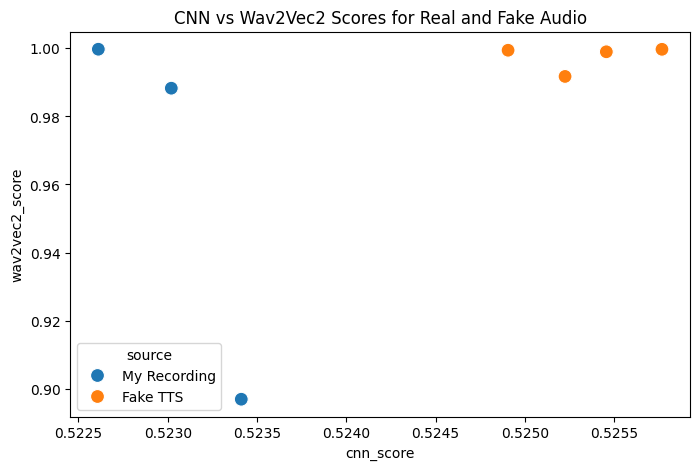

In [191]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=test_results,
    x="cnn_score",
    y="wav2vec2_score",
    hue="source",
    s=100
)

plt.title("CNN vs Wav2Vec2 Scores for Real and Fake Audio")
plt.show()

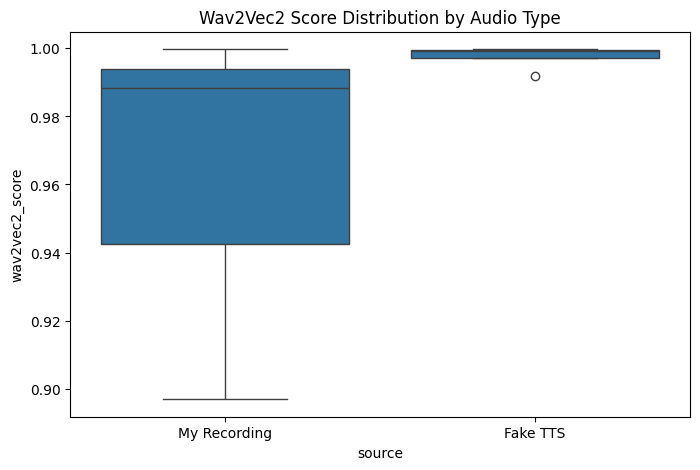

In [192]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=test_results,
    x="source",
    y="wav2vec2_score"
)

plt.title("Wav2Vec2 Score Distribution by Audio Type")

plt.show()

In [193]:
test_results["correct"] = (
    (test_results["source"] == "Fake TTS") & (test_results["prediction"] == "Fake")
) | (
    (test_results["source"] != "Fake TTS") & (test_results["prediction"] == "Real")
)

test_results["correct"].mean()

np.float64(0.5714285714285714)

In [194]:
# ======================================================
# DOWNLOAD LIBRISPEECH (REAL SPEECH)
# ======================================================

!wget -nc https://www.openslr.org/resources/12/dev-clean.tar.gz
!tar -xzf dev-clean.tar.gz

print("Download complete")

File ‘dev-clean.tar.gz’ already there; not retrieving.

Download complete


In [195]:
# ======================================================
# FIND REAL SPEECH FILES
# ======================================================

import os

LIBRI_DIR = "LibriSpeech/dev-clean"

real_files = []

for root, dirs, files in os.walk(LIBRI_DIR):
    for f in files:
        if f.endswith(".flac"):
            real_files.append(os.path.join(root, f))

print("Total LibriSpeech files found:", len(real_files))

# Select 4 samples
real_samples = real_files[:4]

print("Selected samples:")
for f in real_samples:
    print(f)

Total LibriSpeech files found: 2703
Selected samples:
LibriSpeech/dev-clean/1462/170138/1462-170138-0023.flac
LibriSpeech/dev-clean/1462/170138/1462-170138-0010.flac
LibriSpeech/dev-clean/1462/170138/1462-170138-0000.flac
LibriSpeech/dev-clean/1462/170138/1462-170138-0006.flac


In [196]:
# ======================================================
# COPY REAL SPEECH INTO TEST FOLDER
# ======================================================

import shutil

for f in real_samples:
    shutil.copy(f, TEST_DIR)

print("Files now in test folder:")
print(os.listdir(TEST_DIR))

Files now in test folder:
['1462-170138-0023.flac', '1462-170138-0010.flac', '1462-170138-0000.flac', 'my-audio2.flac', '1462-170138-0006.flac', 'generated-female-voice-1.flac', 'my-audio1.flac', 'generated-male-voice-1.flac', 'generated-female-voice-2.flac', 'generated-male-voice-2.flac', 'my-audio.flac']


In [197]:
# ======================================================
# REFRESH FILE LIST
# ======================================================

test_files = os.listdir(TEST_DIR)

print("Files to test:")
for f in test_files:
    print(f)

Files to test:
1462-170138-0023.flac
1462-170138-0010.flac
1462-170138-0000.flac
my-audio2.flac
1462-170138-0006.flac
generated-female-voice-1.flac
my-audio1.flac
generated-male-voice-1.flac
generated-female-voice-2.flac
generated-male-voice-2.flac
my-audio.flac


In [198]:
results = []

In [199]:
results = []

for file in test_files:

    path = os.path.join(TEST_DIR, file)

    print("Processing:", file)

    wav, sr = librosa.load(path, sr=16000)

    wav = normalize_audio(wav)

    # -----------------------------
    # CNN sliding window prediction
    # -----------------------------

    window = 48000
    hop = 16000

    cnn_scores = []

    for start in range(0, len(wav) - window + 1, hop):

        segment = wav[start:start + window]

        spec = compute_spectrogram(segment)

        x = torch.tensor(spec).float().unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            score = torch.sigmoid(spec_cnn_strong_best(x)).cpu().item()

        cnn_scores.append(score)

    cnn_score = np.mean(cnn_scores)

    # -----------------------------
    # Wav2Vec2 prediction
    # -----------------------------

    inputs = processor(
        wav,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = w2v_model(input_values)

    emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

    w2v_score = clf.predict_proba(emb)[0,1]

    # -----------------------------
    # Fusion
    # -----------------------------

    fusion_score = 0.5 * cnn_score + 0.5 * w2v_score

    results.append({
        "file": file,
        "cnn_score": cnn_score,
        "wav2vec2_score": w2v_score,
        "fusion_score": fusion_score
    })

print("Finished processing")

Processing: 1462-170138-0023.flac
Processing: 1462-170138-0010.flac
Processing: 1462-170138-0000.flac
Processing: my-audio2.flac
Processing: 1462-170138-0006.flac
Processing: generated-female-voice-1.flac
Processing: my-audio1.flac
Processing: generated-male-voice-1.flac
Processing: generated-female-voice-2.flac
Processing: generated-male-voice-2.flac
Processing: my-audio.flac
Finished processing


In [200]:
import pandas as pd

test_results = pd.DataFrame(results)

test_results["prediction"] = test_results["fusion_score"].apply(
    lambda x: "Fake" if x > 0.5 else "Real"
)

test_results.sort_values("fusion_score", ascending=False)

,file,cnn_score,wav2vec2_score,fusion_score,prediction
8,generated-female-voice-2.flac,0.525767,0.999726,0.762746,Fake
7,generated-male-voice-1.flac,0.525456,0.998997,0.762226,Fake
9,generated-male-voice-2.flac,0.524905,0.999452,0.762179,Fake
10,my-audio.flac,0.522611,0.999750,0.761181,Fake
5,generated-female-voice-1.flac,0.525224,0.991754,0.758489,Fake
6,my-audio1.flac,0.523020,0.988296,0.755658,Fake
4,1462-170138-0006.flac,0.520896,0.915270,0.718083,Fake
3,my-audio2.flac,0.523412,0.896890,0.710151,Fake
1,1462-170138-0010.flac,0.520794,0.779871,0.650333,Fake
2,1462-170138-0000.flac,0.519935,0.759357,0.639646,Fake


In [201]:
# ======================================================
# LABEL AUDIO SOURCES
# ======================================================

def label_source(name):

    if "generated" in name:
        return "Fake TTS"

    if "my-audio" in name:
        return "My Recording"

    if "-" in name and name.endswith(".flac"):
        return "Internet Real Speech"

    return "Unknown"

test_results["source"] = test_results["file"].apply(label_source)

test_results

,file,cnn_score,wav2vec2_score,fusion_score,prediction,source
0,1462-170138-0023.flac,0.520166,0.612801,0.566483,Fake,Internet Real Speech
1,1462-170138-0010.flac,0.520794,0.779871,0.650333,Fake,Internet Real Speech
2,1462-170138-0000.flac,0.519935,0.759357,0.639646,Fake,Internet Real Speech
3,my-audio2.flac,0.523412,0.896890,0.710151,Fake,My Recording
4,1462-170138-0006.flac,0.520896,0.915270,0.718083,Fake,Internet Real Speech
5,generated-female-voice-1.flac,0.525224,0.991754,0.758489,Fake,Fake TTS
6,my-audio1.flac,0.523020,0.988296,0.755658,Fake,My Recording
7,generated-male-voice-1.flac,0.525456,0.998997,0.762226,Fake,Fake TTS
8,generated-female-voice-2.flac,0.525767,0.999726,0.762746,Fake,Fake TTS
9,generated-male-voice-2.flac,0.524905,0.999452,0.762179,Fake,Fake TTS


In [202]:
import pandas as pd

summary = test_results.groupby("source").agg(
    total_files=("file", "count"),
    predicted_real=("prediction", lambda x: (x == "Real").sum()),
    predicted_fake=("prediction", lambda x: (x == "Fake").sum())
)

summary["accuracy_estimate"] = summary.apply(
    lambda row: row["predicted_fake"]/row["total_files"]
    if row.name == "Fake TTS"
    else row["predicted_real"]/row["total_files"],
    axis=1
)

summary

,total_files,predicted_real,predicted_fake,accuracy_estimate
source,,,,
Fake TTS,4,0,4,1.0
Internet Real Speech,4,0,4,0.0
My Recording,3,0,3,0.0


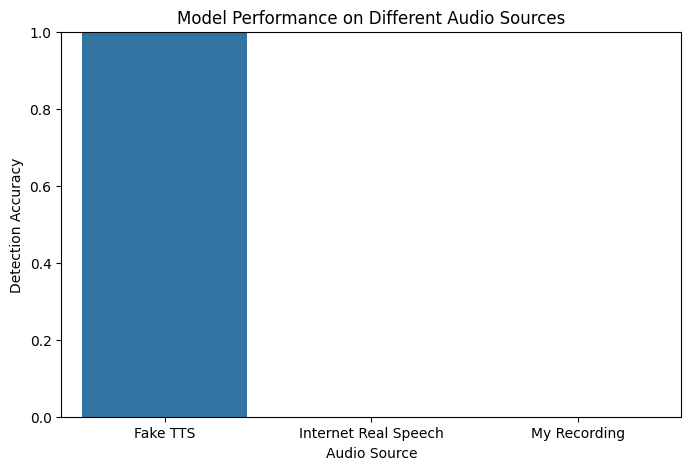

In [203]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x=summary.index,
    y=summary["accuracy_estimate"]
)

plt.ylabel("Detection Accuracy")
plt.xlabel("Audio Source")
plt.title("Model Performance on Different Audio Sources")

plt.ylim(0,1)

plt.show()

In [ ]:
'''import os

cache = RESULTS_DIR / "wav2vec2_eval_predictions.npy"

if cache.exists():
    os.remove(cache)
    print("Deleted old cache")
else:
    print("Cache not found")

Deleted old cache


In [ ]:
'''# ======================================================
# WAV2VEC2 EVAL PREDICTIONS (CACHED)
# ======================================================

PRED_CACHE = RESULTS_DIR / "wav2vec2_eval_predictions.npy"

print("Prediction cache exists:", PRED_CACHE.exists())

if PRED_CACHE.exists():

    print("Loading cached predictions")

    scores_eval_w2v2 = np.load(PRED_CACHE)

else:

    print("Computing predictions")

    scores_eval_w2v2 = clf.predict_proba(X_eval_w2v2)[:,1]

    np.save(PRED_CACHE, scores_eval_w2v2)

    print("Saved predictions:", PRED_CACHE)

print("Prediction vector length:", len(scores_eval_w2v2))

Prediction cache exists: False
Computing predictions
Saved predictions: /content/drive/MyDrive/deepfake_audio/results/wav2vec2_eval_predictions.npy
Prediction vector length: 4000


In [ ]:
# ======================================================
# WAV2VEC2 EVAL METRICS (CACHED)
# ======================================================

import json

METRIC_CACHE = RESULTS_DIR / "wav2vec2_eval_metrics.json"

print("Metric cache exists:", METRIC_CACHE.exists())

if METRIC_CACHE.exists():

    print("Loading cached metrics")

    with open(METRIC_CACHE, "r") as f:
        metrics = json.load(f)

    auc_w2v2 = metrics["auc"]
    eer_w2v2 = metrics["eer"]

else:

    print("Computing metrics")

    y = y_eval_w2v2
    s = scores_eval_w2v2

    auc_w2v2 = roc_auc_score(y, s)
    eer_w2v2 = compute_eer(y, s)

    metrics = {
        "auc": float(auc_w2v2),
        "eer": float(eer_w2v2)
    }

    with open(METRIC_CACHE, "w") as f:
        json.dump(metrics, f)

    print("Saved metrics:", METRIC_CACHE)

print("Wav2Vec2 Eval AUC:", auc_w2v2)
print("Wav2Vec2 Eval EER:", eer_w2v2)

Metric cache exists: False
Computing metrics
Saved metrics: /content/drive/MyDrive/deepfake_audio/results/wav2vec2_eval_metrics.json
Wav2Vec2 Eval AUC: 0.9882806012290317
Wav2Vec2 Eval EER: 0.061202458063444626


In [ ]:
# ======================================================
# MODEL COMPARISON
# ======================================================

import pandas as pd

comparison = pd.DataFrame([
    {
        "model": "SpecCNN Strong",
        "AUC": auc,
        "EER": eer
    },
    {
        "model": "Wav2Vec2 + Logistic Regression",
        "AUC": auc_w2v2,
        "EER": eer_w2v2
    }
])

comparison

,model,AUC,EER
0,SpecCNN Strong,0.989315,0.037179
1,Wav2Vec2 + Logistic Regression,0.988281,0.061202


In [ ]:
# ======================================================
# FUSION SETUP: IMPORTS + HELPERS
# ======================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

FUSION_DIR = RESULTS_DIR / "fusion"
FUSION_DIR.mkdir(parents=True, exist_ok=True)

def compute_eer_from_scores(y_true, scores):
    """
    If your notebook already has compute_eer(y, s), this wrapper uses it.
    Otherwise it computes EER from ROC curve.
    """
    try:
        return compute_eer(y_true, scores)
    except NameError:
        fpr, tpr, thresholds = roc_curve(y_true, scores)
        fnr = 1 - tpr
        idx = np.nanargmin(np.abs(fnr - fpr))
        return float((fpr[idx] + fnr[idx]) / 2.0)

def save_json(path, obj):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

print("Fusion directory:", FUSION_DIR)

Fusion directory: /content/drive/MyDrive/deepfake_audio/results/fusion


In [ ]:
# ======================================================
# LOAD SPEC_CNN_STRONG MODEL
# ======================================================

MODEL_DIR = BASE_DIR / "models"

spec_cnn_strong_best = SpecCNN_Strong().to(device)

spec_cnn_strong_best.load_state_dict(
    torch.load(MODEL_DIR / "spec_cnn_strong_best.pt", map_location=device)
)

spec_cnn_strong_best.eval()

print("SpecCNN_Strong model loaded successfully")

SpecCNN_Strong model loaded successfully


In [ ]:
'''# ======================================================
# EVAL METRICS
# ======================================================

from sklearn.metrics import roc_curve, roc_auc_score

def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return eer

auc = roc_auc_score(labels, scores)
eer = compute_eer(labels, scores)

print("=== STRONG CNN ON EVAL ===")
print("AUC:", round(auc, 6))
print("EER:", round(eer, 6))


In [ ]:
'''# ======================================================
# PER-ATTACK EVAL ANALYSIS
# ======================================================

per_attack_results = []

bonafide_df = eval_scores_df[eval_scores_df["attack_id"] == "-"]

for attack in sorted(eval_scores_df["attack_id"].unique()):
    if attack == "-":
        continue

    spoof_subset = eval_scores_df[eval_scores_df["attack_id"] == attack]
    combined = pd.concat([bonafide_df, spoof_subset])

    y = combined["label"].values
    s = combined["score"].values

    if len(np.unique(y)) < 2:
        continue

    auc_attack = roc_auc_score(y, s)
    eer_attack = compute_eer(y, s)

    per_attack_results.append({
        "attack_id": attack,
        "AUC": auc_attack,
        "EER": eer_attack
    })

eval_attack_df = (
    pd.DataFrame(per_attack_results)
    .sort_values("EER")
    .reset_index(drop=True)
)

EVAL_ATTACK_FILE = RESULTS_DIR / "per_attack_results_strong_eval.csv"
eval_attack_df.to_csv(EVAL_ATTACK_FILE, index=False)

print("Saved:", EVAL_ATTACK_FILE)
display(eval_attack_df)


In [ ]:
'''print(eval_scores_df[eval_scores_df["attack_id"] == "A17"]["score"].describe())


In [ ]:
''''# ============================================================
# OVERALL CONFUSION MATRIX (EVAL)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load scores
df = pd.read_csv(BASE_DIR / "results" / "eval_scores_strong.csv")

# Compute overall EER threshold
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(df["label"], df["score"], pos_label=1)
fnr = 1 - tpr
idx = np.nanargmin(np.abs(fpr - fnr))
thr = thresholds[idx]

y_pred = (df["score"] >= thr).astype(int)

cm = confusion_matrix(df["label"], y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["bonafide", "spoof"],
            yticklabels=["bonafide", "spoof"])
plt.title("Overall Confusion Matrix (EVAL @ EER threshold)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
'''# ============================================================
# CONFUSION MATRIX FOR A SPECIFIC ATTACK
# ============================================================

attack = "A17"

bonafide_df = df[df["attack_id"] == "-"]
spoof_df = df[df["attack_id"] == attack]

combined = pd.concat([bonafide_df, spoof_df])

fpr, tpr, thresholds = roc_curve(combined["label"], combined["score"], pos_label=1)
fnr = 1 - tpr
idx = np.nanargmin(np.abs(fpr - fnr))
thr_attack = thresholds[idx]

y_pred_attack = (combined["score"] >= thr_attack).astype(int)

cm_attack = confusion_matrix(combined["label"], y_pred_attack)

plt.figure(figsize=(6,5))
sns.heatmap(cm_attack, annot=True, fmt="d",
            xticklabels=["bonafide", "spoof"],
            yticklabels=["bonafide", "spoof"])
plt.title(f"Confusion Matrix - {attack}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
'''# ============================================================
# SCORE DISTRIBUTION PLOT
# ============================================================

attack = "A17"

bonafide_scores = df[df["attack_id"] == "-"]["score"]
spoof_scores = df[df["attack_id"] == attack]["score"]

plt.figure(figsize=(8,5))
plt.hist(bonafide_scores, bins=50, alpha=0.5, label="bonafide", density=True)
plt.hist(spoof_scores, bins=50, alpha=0.5, label=f"{attack}", density=True)

plt.title(f"Score Distribution - {attack}")
plt.xlabel("Spoof Probability")
plt.ylabel("Density")
plt.legend()
plt.show()


In [ ]:
'''# ============================================================
# ROC CURVE FOR A SPECIFIC ATTACK
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

attack = "A17"

bonafide_df = df[df["attack_id"] == "-"]
spoof_df = df[df["attack_id"] == attack]
combined = pd.concat([bonafide_df, spoof_df])

y = combined["label"]
s = combined["score"]

auc = roc_auc_score(y, s)
fpr, tpr, _ = roc_curve(y, s)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.title(f"ROC Curve - {attack} (AUC={auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


In [ ]:
'''# ============================================================
# BAR PLOT OF EER PER ATTACK
# ============================================================

attack_df = pd.read_csv(BASE_DIR / "results" / "per_attack_results_strong_eval.csv")

plt.figure(figsize=(10,5))
plt.bar(attack_df["attack_id"], attack_df["EER"])
plt.xticks(rotation=45)
plt.title("EER by Attack (EVAL)")
plt.ylabel("EER")
plt.show()


In [ ]:
'''# ======================================================
# EXPERIMENT 1 — FFT 2048 SETUP
# ======================================================

EXP_TAG = "strong_fft2048"

SPECT_CACHE_DIR_FFT = BASE_DIR / "spect_cache_fft2048"
SPECT_CACHE_DIR_FFT.mkdir(parents=True, exist_ok=True)

print("Experiment tag:", EXP_TAG)
print("Cache dir:", SPECT_CACHE_DIR_FFT)

In [ ]:
'''# ======================================================
# LOG-MEL DATASET (FFT 2048 VERSION)
# ======================================================

N_FFT_EXP = 2048   # Only change
MAX_SECONDS_EXP = MAX_SECONDS  # keep same context

class LogMelDatasetFFT(torch.utils.data.Dataset):

    def __init__(self, df, split_dir, split_name, augment=False):
        self.df = df.reset_index(drop=True)
        self.split_dir = split_dir
        self.augment = augment

        self.cache_dir = SPECT_CACHE_DIR_FFT / split_name
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_id = row["file_id"]
        label_str = row["label_str"]
        y_val = 1 if label_str == "spoof" else 0

        cache_path = self.cache_dir / f"{file_id}.npy"

        if cache_path.exists():
            logmel = np.load(cache_path)

        else:
            audio_path = resolve_audio_path(self.split_dir, file_id)

            y, sr = librosa.load(str(audio_path), sr=SR)

            target_len = int(MAX_SECONDS_EXP * SR)
            if len(y) < target_len:
                y = np.pad(y, (0, target_len - len(y)))
            else:
                y = y[:target_len]

            mel = librosa.feature.melspectrogram(
                y=y,
                sr=sr,
                n_fft=N_FFT_EXP,
                hop_length=HOP_LENGTH,
                win_length=WIN_LENGTH,
                n_mels=N_MELS,
                fmin=FMIN,
                fmax=FMAX,
                power=2.0
            )

            logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
            np.save(cache_path, logmel)

        x = torch.from_numpy(logmel).unsqueeze(0)
        y = torch.tensor(y_val, dtype=torch.float32)

        return x, y

In [ ]:
'''train_ds_fft = LogMelDatasetFFT(train_df, TRAIN_DIR, "train", augment=True)
dev_ds_fft   = LogMelDatasetFFT(dev_df,   DEV_DIR,   "dev",   augment=False)

train_loader_fft = DataLoader(
    train_ds_fft,
    batch_size=64,
    sampler=sampler,
    num_workers=2
)

dev_loader_fft = DataLoader(
    dev_ds_fft,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("FFT 2048 datasets ready.")


In [ ]:
'''# ======================================================
#  DONT RUN ON LOW GPU----------TRAIN STRONG CNN (FFT 2048)
# ======================================================

BEST_CKPT_FFT = MODEL_DIR / "spec_cnn_strong_fft2048_best.pt"

model_fft = SpecCNN_Strong().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_fft.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 8
best_dev = float("inf")

for epoch in range(1, EPOCHS + 1):

    tr_loss = train_one_epoch(model_fft, train_loader_fft)
    dv_loss = eval_loss(model_fft, dev_loader_fft)

    print(f"[FFT2048] Epoch {epoch} | train={tr_loss:.4f} | dev={dv_loss:.4f}")

    if dv_loss < best_dev:
        best_dev = dv_loss
        torch.save(model_fft.state_dict(), BEST_CKPT_FFT)
        print("Saved FFT2048 checkpoint.")

In [ ]:
'''DEV_SCORE_FILE = RESULTS_DIR / "dev_scores_strong_fft2048.csv"

In [ ]:
'''# ============================================================
# PATHS FOR DELTA MODEL
# ============================================================

from pathlib import Path

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT_DELTA = MODEL_DIR / "spec_cnn_delta_best.pt"

print("Saving to:", BEST_CKPT_DELTA)
print("Checkpoint exists:", BEST_CKPT_DELTA.exists())


In [ ]:
'''# ============================================================
# DELTA DATASET CLASS (ROBUST + STABLE VERSION)
# ============================================================

class LogMelDeltaDataset(torch.utils.data.Dataset):
    def __init__(self, df, split_dir: Path, split_name: str, augment=False):
        self.df = df.reset_index(drop=True)
        self.split_dir = split_dir
        self.augment = augment

        self.cache_dir = SPECT_CACHE_DIR / f"{split_name}_delta"
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_id = row["file_id"]
        label_str = row["label_str"]
        y_val = label_to_y[label_str]

        cache_path = self.cache_dir / f"{file_id}.npy"

        # ------------------------------------------------------------
        # LOAD FROM CACHE IF EXISTS
        # ------------------------------------------------------------
        if cache_path.exists():
            x = np.load(cache_path)

        else:
            audio_path = resolve_audio_path(self.split_dir, file_id)

            # ------------------------------------------------------------
            # SAFETY: missing file
            # ------------------------------------------------------------
            if audio_path is None:
                x = np.zeros((3, N_MELS, MAX_FRAMES), dtype=np.float32)

            else:
                # ------------------------------------------------------------
                # SAFE AUDIO LOAD
                # ------------------------------------------------------------
                try:
                    y_audio, sr = librosa.load(
                        str(audio_path),
                        sr=SR,
                        mono=True
                    )
                except Exception as e:
                    print(f"[WARNING] Audio load failed for {file_id}: {e}")
                    x = np.zeros((3, N_MELS, MAX_FRAMES), dtype=np.float32)
                    np.save(cache_path, x)
                    x = torch.from_numpy(x)
                    y = torch.tensor(y_val, dtype=torch.float32)
                    return x, y

                # ------------------------------------------------------------
                # FIX LENGTH
                # ------------------------------------------------------------
                target_len = int(MAX_SECONDS * SR)

                if len(y_audio) < target_len:
                    y_audio = np.pad(y_audio, (0, target_len - len(y_audio)))
                else:
                    y_audio = y_audio[:target_len]

                # ------------------------------------------------------------
                # MEL SPECTROGRAM
                # ------------------------------------------------------------
                mel = librosa.feature.melspectrogram(
                    y=y_audio,
                    sr=sr,
                    n_fft=N_FFT,
                    hop_length=HOP_LENGTH,
                    win_length=WIN_LENGTH,
                    n_mels=N_MELS,
                    fmin=FMIN,
                    fmax=FMAX,
                    power=2.0
                )

                logmel = librosa.power_to_db(mel, ref=np.max)

                # ------------------------------------------------------------
                # DELTA FEATURES
                # ------------------------------------------------------------
                delta = librosa.feature.delta(logmel)
                delta2 = librosa.feature.delta(logmel, order=2)

                # ------------------------------------------------------------
                # PAD / TRUNCATE TIME
                # ------------------------------------------------------------
                T = logmel.shape[1]

                if T < MAX_FRAMES:
                    pad_val = logmel.min()
                    pad_width = MAX_FRAMES - T

                    logmel = np.pad(logmel, ((0,0),(0,pad_width)), constant_values=pad_val)
                    delta = np.pad(delta, ((0,0),(0,pad_width)), constant_values=0)
                    delta2 = np.pad(delta2, ((0,0),(0,pad_width)), constant_values=0)
                else:
                    logmel = logmel[:, :MAX_FRAMES]
                    delta = delta[:, :MAX_FRAMES]
                    delta2 = delta2[:, :MAX_FRAMES]

                # ------------------------------------------------------------
                # STACK CHANNELS
                # ------------------------------------------------------------
                x = np.stack([logmel, delta, delta2]).astype(np.float32)

                # ------------------------------------------------------------
                # PER-CHANNEL NORMALIZATION (CRITICAL)
                # ------------------------------------------------------------
                for c in range(3):
                    mean = x[c].mean()
                    std = x[c].std() + 1e-6
                    x[c] = (x[c] - mean) / std

            # ------------------------------------------------------------
            # SAVE TO CACHE
            # ------------------------------------------------------------
            np.save(cache_path, x)

        # ------------------------------------------------------------
        # CONVERT TO TENSOR
        # ------------------------------------------------------------
        x = torch.from_numpy(x)

        if self.augment:
            x[0:1] = spec_augment(x[0:1])  # augment logmel only

        y = torch.tensor(y_val, dtype=torch.float32)

        return x, y


In [ ]:
'''# ============================================================
# DELTA MODEL DEFINITION (RELOAD AFTER RUNTIME RESET)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class BiggerSpecCNN_Delta(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.25)
        )

        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = x.mean(dim=(2,3))   # global average pooling
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        return self.fc2(x).squeeze(1)


In [ ]:
'''# ============================================================
# FINAL DELTA TRAINING (WITH POS_WEIGHT FIX)
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT_DELTA = MODEL_DIR / "spec_cnn_delta_best.pt"
print("Saving to:", BEST_CKPT_DELTA)

# ------------------------------------------------------------
# Instantiate datasets
# ------------------------------------------------------------

train_ds_delta = LogMelDeltaDataset(train_df, TRAIN_DIR, "train", augment=True)
dev_ds_delta   = LogMelDeltaDataset(dev_df,   DEV_DIR,   "dev",   augment=False)

train_loader_delta = DataLoader(
    train_ds_delta,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

dev_loader_delta = DataLoader(
    dev_ds_delta,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("Delta dataset ready.")
print("Train size:", len(train_ds_delta))
print("Dev size:", len(dev_ds_delta))

# ------------------------------------------------------------
# Compute pos_weight
# ------------------------------------------------------------

n_bonafide = (train_df["label_str"] == "bonafide").sum()
n_spoof    = (train_df["label_str"] == "spoof").sum()

print("Bonafide:", n_bonafide)
print("Spoof:", n_spoof)

pos_weight_value = n_bonafide / n_spoof
print("Using pos_weight:", pos_weight_value)

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

model_delta = BiggerSpecCNN_Delta().to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model_delta.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("Training delta model with pos_weight...")

best_dev = float("inf")

for epoch in range(1, 6):
    tr_loss = train_one_epoch(model_delta, train_loader_delta)
    dv_loss = eval_loss(model_delta, dev_loader_delta)

    print(f"Epoch {epoch}/5 | train={tr_loss:.4f} | dev={dv_loss:.4f}")

    if dv_loss < best_dev:
        best_dev = dv_loss
        torch.save(model_delta.state_dict(), BEST_CKPT_DELTA)
        print("Saved best delta checkpoint.")

print("READY FOR EVALUATION.")


In [ ]:
'''# ============================================================
# DELTA EVALUATION (Per-Attack AUC + Overall AUC)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

# 🔹 Change per experiment
MODEL_NAME = "delta"   # "baseline", "delta", "gru", etc.

RESULTS_PATH = BASE_DIR / "results" / f"dev_scores_{MODEL_NAME}.csv"

print("Loading:", RESULTS_PATH)
df = pd.read_csv(RESULTS_PATH)

print("Loaded:", df.shape)

# Map labels if needed
if df["label"].dtype not in [np.int64, np.int32]:
    df["label"] = df["label_str"].map({"bonafide": 0, "spoof": 1})

# ------------------------------------------------------------
# Overall AUC
# ------------------------------------------------------------

overall_auc = roc_auc_score(df["label"], df["score"])
print(f"\nOverall AUC = {overall_auc:.6f}")

# ------------------------------------------------------------
# Per-Attack AUC
# ------------------------------------------------------------

print("\nPer-Attack AUC:")

bon = df[df["attack_id"] == "-"]

for attack in sorted(df["attack_id"].unique()):
    if attack == "-":
        continue

    attack_df = df[df["attack_id"] == attack]
    subset = pd.concat([bon, attack_df], ignore_index=True)

    auc = roc_auc_score(subset["label"], subset["score"])
    print(f"{attack} AUC = {auc:.6f}")


In [ ]:
'''# ============================================================
# DELTA MODEL — DEV INFERENCE + EVALUATION (FINAL CLEAN)
# ============================================================

import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_delta.eval()

all_scores = []
all_labels = []
all_attack_ids = []

print("Running inference on DEV set...")

with torch.no_grad():
    for x, y in tqdm(dev_loader_delta):
        x = x.to(device)
        logits = model_delta(x)
        probs = torch.sigmoid(logits).view(-1)

        all_scores.extend(probs.cpu().numpy())
        all_labels.extend(y.numpy())

# Build results dataframe
dev_results = dev_df.copy().reset_index(drop=True)
dev_results["score"] = np.array(all_scores)
dev_results["label"] = dev_results["label_str"].map({"bonafide": 0, "spoof": 1})

print("Collected scores:", dev_results["score"].shape)
print("Merged results shape:", dev_results.shape)

# ============================================================
# OVERALL METRICS
# ============================================================

y_true = dev_results["label"].values.astype(int)
y_score = dev_results["score"].values.astype(float)

overall_auc = roc_auc_score(y_true, y_score)

fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
overall_eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0

print("\n=== OVERALL DELTA RESULTS ===")
print("AUC:", round(overall_auc, 6))
print("EER:", round(overall_eer, 6))

# ============================================================
# PER-ATTACK METRICS (CORRECT: bonafide vs each attack)
# ============================================================

attack_results = []

bonafide = dev_results[dev_results["attack_id"] == "-"]

for attack in sorted(dev_results["attack_id"].unique()):
    if attack == "-":
        continue

    spoof = dev_results[dev_results["attack_id"] == attack]
    subset = pd.concat([bonafide, spoof], ignore_index=True)

    y_true = subset["label"].values.astype(int)
    y_score = subset["score"].values.astype(float)

    if len(np.unique(y_true)) < 2:
        print(f"[SKIP] {attack}: only one class present")
        continue

    auc = roc_auc_score(y_true, y_score)

    fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0

    attack_results.append({
        "attack_id": attack,
        "samples_spoof": len(spoof),
        "AUC": float(auc),
        "EER": float(eer)
    })

attack_df = pd.DataFrame(attack_results).sort_values("EER")

print("\n=== DELTA Per-Attack Results ===")
print(attack_df)

print("\n=== A06 RESULT ===")
print(attack_df[attack_df["attack_id"] == "A06"])

# ============================================================
# SCORE DISTRIBUTION CHECK
# ============================================================

print("\n=== SCORE STATS ===")
print("Min:", dev_results["score"].min())
print("Max:", dev_results["score"].max())
print("Mean:", dev_results["score"].mean())
print("Std:", dev_results["score"].std())


In [ ]:
'''# ============================================================
# DELTA MODEL — DEV INFERENCE + EVALUATION (FINAL CLEAN)
# ============================================================

import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_delta.eval()

all_scores = []
all_labels = []
all_attack_ids = []

print("Running inference on DEV set...")

with torch.no_grad():
    for x, y in tqdm(dev_loader_delta):
        x = x.to(device)
        logits = model_delta(x)
        probs = torch.sigmoid(logits).view(-1)

        all_scores.extend(probs.cpu().numpy())
        all_labels.extend(y.numpy())

# Build results dataframe
dev_results = dev_df.copy().reset_index(drop=True)
dev_results["score"] = np.array(all_scores)
dev_results["label"] = dev_results["label_str"].map({"bonafide": 0, "spoof": 1})

print("Collected scores:", dev_results["score"].shape)
print("Merged results shape:", dev_results.shape)

# ============================================================
# OVERALL METRICS
# ============================================================

y_true = dev_results["label"].values.astype(int)
y_score = dev_results["score"].values.astype(float)

overall_auc = roc_auc_score(y_true, y_score)

fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
overall_eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0

print("\n=== OVERALL DELTA RESULTS ===")
print("AUC:", round(overall_auc, 6))
print("EER:", round(overall_eer, 6))

# ============================================================
# PER-ATTACK METRICS (CORRECT: bonafide vs each attack)
# ============================================================

attack_results = []

bonafide = dev_results[dev_results["attack_id"] == "-"]

for attack in sorted(dev_results["attack_id"].unique()):
    if attack == "-":
        continue

    spoof = dev_results[dev_results["attack_id"] == attack]
    subset = pd.concat([bonafide, spoof], ignore_index=True)

    y_true = subset["label"].values.astype(int)
    y_score = subset["score"].values.astype(float)

    if len(np.unique(y_true)) < 2:
        print(f"[SKIP] {attack}: only one class present")
        continue

    auc = roc_auc_score(y_true, y_score)

    fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0

    attack_results.append({
        "attack_id": attack,
        "samples_spoof": len(spoof),
        "AUC": float(auc),
        "EER": float(eer)
    })

attack_df = pd.DataFrame(attack_results).sort_values("EER")

print("\n=== DELTA Per-Attack Results ===")
print(attack_df)

print("\n=== A06 RESULT ===")
print(attack_df[attack_df["attack_id"] == "A06"])

# ============================================================
# SCORE DISTRIBUTION CHECK
# ============================================================

print("\n=== SCORE STATS ===")
print("Min:", dev_results["score"].min())
print("Max:", dev_results["score"].max())
print("Mean:", dev_results["score"].mean())
print("Std:", dev_results["score"].std())
